# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
# Basic dataset inspection
print("Shape:", df_reviews.shape)
print("\nColumns:")
print(df_reviews.columns.tolist())

display(df_reviews.head())

print("\nDataset info:")
df_reviews.info()

Shape: (47331, 17)

Columns:
['tconst', 'title_type', 'primary_title', 'original_title', 'start_year', 'end_year', 'runtime_minutes', 'is_adult', 'genres', 'average_rating', 'votes', 'review', 'rating', 'sp', 'pos', 'ds_part', 'idx']


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dt

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Initial Dataset Overview

The dataset was loaded successfully and contains 47,331 observations across 17 columns, indicating a sufficiently large corpus for building and evaluating sentiment classification models. The presence of both review text and supporting metadata provides useful context for exploratory analysis, although the primary focus of this project will remain on the `review` text and the binary sentiment target `pos`.

A preliminary inspection of the first few rows shows that the dataset includes both textual and movie-level attributes such as title information, release year, genre, average rating, and vote count. Most importantly, the key fields required for the sentiment modeling task are present: `review` contains the raw text data, `pos` provides the binary target labels, and `ds_part` defines the predefined train-test split. This confirms that the dataset is organized in a way that aligns directly with the project requirements.

The data types also appear appropriate for analysis. Numerical fields such as `start_year`, `rating`, and `pos` were correctly interpreted as numeric variables, while textual and categorical descriptors were read as object types. At this stage, the dataset structure appears coherent and suitable for further validation, exploratory analysis, and downstream preprocessing. The next step is to confirm missing values, label consistency, and class balance before moving into deeper text analysis and model construction.

</div>

In [6]:
# Missing values and label integrity checks
print("Missing values per column:")
print(df_reviews.isna().sum().sort_values(ascending=False))

print("\nUnique values in 'pos':")
print(sorted(df_reviews['pos'].unique()))

print("\nUnique values in 'ds_part':")
print(df_reviews['ds_part'].unique())

print("\nOverall class distribution:")
print(df_reviews['pos'].value_counts().sort_index())

print("\nTrain/test split distribution:")
print(df_reviews['ds_part'].value_counts())

print("\nClass distribution within each split:")
print(df_reviews.groupby('ds_part')['pos'].value_counts().sort_index())

Missing values per column:
average_rating     2
votes              2
tconst             0
ds_part            0
pos                0
sp                 0
rating             0
review             0
genres             0
title_type         0
is_adult           0
runtime_minutes    0
end_year           0
start_year         0
original_title     0
primary_title      0
idx                0
dtype: int64

Unique values in 'pos':
[0, 1]

Unique values in 'ds_part':
['train' 'test']

Overall class distribution:
0    23715
1    23616
Name: pos, dtype: int64

Train/test split distribution:
train    23796
test     23535
Name: ds_part, dtype: int64

Class distribution within each split:
ds_part  pos
test     0      11803
         1      11732
train    0      11912
         1      11884
Name: pos, dtype: int64


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Data Integrity and Class Balance

The dataset passed the initial validation checks successfully. The core fields required for sentiment classification, namely `review`, `pos`, and `ds_part`, contain no missing values, which confirms that the dataset is structurally suitable for supervised text modeling. Only two missing values were found in `average_rating` and `votes`, and since these columns are not essential for the primary text-based pipeline, they do not pose a meaningful issue for model development.

The target variable `pos` contains only the expected binary labels, `0` and `1`, while the split variable `ds_part` contains only `train` and `test`, confirming that the predefined partitioning is valid and ready for use. In addition, the class distribution is highly balanced both overall and within the training and test subsets. Negative and positive reviews appear in nearly equal proportions, which reduces the risk of bias toward one class during training and allows evaluation metrics such as F1 score to be interpreted more reliably.

Overall, the dataset shows strong integrity, clean label structure, and no significant class imbalance. This means that the main modeling challenge will not be correcting skewed target distributions, but rather building effective text representations capable of capturing sentiment patterns in natural language.

</div>

In [7]:
# Duplicate and text-quality checks
print("Duplicate rows:", df_reviews.duplicated().sum())
print("Duplicate review texts:", df_reviews['review'].duplicated().sum())

review_stripped = df_reviews['review'].str.strip()
print("Empty or whitespace-only reviews:", (review_stripped == "").sum())

df_reviews['review_len_chars'] = df_reviews['review'].str.len()
df_reviews['review_len_words'] = df_reviews['review'].str.split().str.len()

print("\nReview length statistics (characters):")
print(df_reviews['review_len_chars'].describe())

print("\nReview length statistics (words):")
print(df_reviews['review_len_words'].describe())

Duplicate rows: 0
Duplicate review texts: 91
Empty or whitespace-only reviews: 0

Review length statistics (characters):
count    47331.000000
mean      1290.030973
std        974.976807
min         32.000000
25%        691.000000
50%        957.000000
75%       1566.000000
max      13594.000000
Name: review_len_chars, dtype: float64

Review length statistics (words):
count    47331.000000
mean       229.428831
std        170.075447
min          4.000000
25%        125.500000
50%        172.000000
75%        278.000000
max       2459.000000
Name: review_len_words, dtype: float64


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Text Quality and Review Length Assessment

The text quality checks indicate that the review corpus is in good condition for sentiment modeling. There are no fully duplicated rows and no empty or whitespace-only reviews, which confirms that the dataset does not contain obvious structural noise that would interfere with vectorization or model training. Although 91 duplicated review texts were identified, this is a very small fraction of the full dataset and does not immediately suggest a major data quality issue. However, duplicated texts should still be checked across the train and test partitions to rule out potential leakage.

The review length statistics show substantial variation in document size. Reviews range from very short entries of only a few words to long-form texts containing thousands of words. The median review length is 172 words, while the upper range extends far beyond that, indicating a diverse corpus of user writing styles and detail levels. This is an important modeling consideration, since the classifier must generalize across both concise and highly detailed reviews.

Overall, the text data appears clean, non-empty, and sufficiently rich for sentiment analysis. The wide spread in review length reinforces the suitability of flexible vectorization methods such as TF-IDF, which can represent variable-length text effectively without requiring strict sequence alignment.

</div>

In [8]:
# Check whether duplicate review texts appear across train and test
dup_reviews = df_reviews[df_reviews['review'].duplicated(keep=False)].copy()

cross_split_dups = (
    dup_reviews.groupby('review')['ds_part']
    .nunique()
    .value_counts()
    .sort_index()
)

print("Duplicate reviews grouped by number of unique splits represented:")
print(cross_split_dups)

cross_split_examples = (
    dup_reviews.groupby('review')['ds_part']
    .nunique()
    .reset_index(name='n_splits')
)

print("\nNumber of duplicated review texts appearing in both train and test:")
print((cross_split_examples['n_splits'] > 1).sum())

Duplicate reviews grouped by number of unique splits represented:
1    81
2     1
Name: ds_part, dtype: int64

Number of duplicated review texts appearing in both train and test:
1


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Duplicate Review Check and Leakage Risk

A duplicate-text inspection was performed to evaluate the possibility of data leakage between the training and test partitions. Most duplicated review texts were confined to a single split, which does not threaten the integrity of model evaluation. Only one duplicated review text was found to appear across both the training and test sets.

From an analytical standpoint, this indicates that the risk of train-test leakage through duplicated text is extremely low. Given the overall dataset size, a single overlapping review is not substantial enough to meaningfully inflate performance metrics or compromise the validity of the modeling pipeline. Therefore, the dataset remains suitable for proceeding to exploratory analysis and text preprocessing without requiring immediate corrective action.

Overall, the validation stage confirms that the dataset is clean, structurally consistent, and appropriate for sentiment classification. Any remaining challenges are expected to come from the natural complexity of the text itself rather than from data quality issues.

</div>

## Exploratory Data Analysis

Let's check the number of movies and reviews over years.

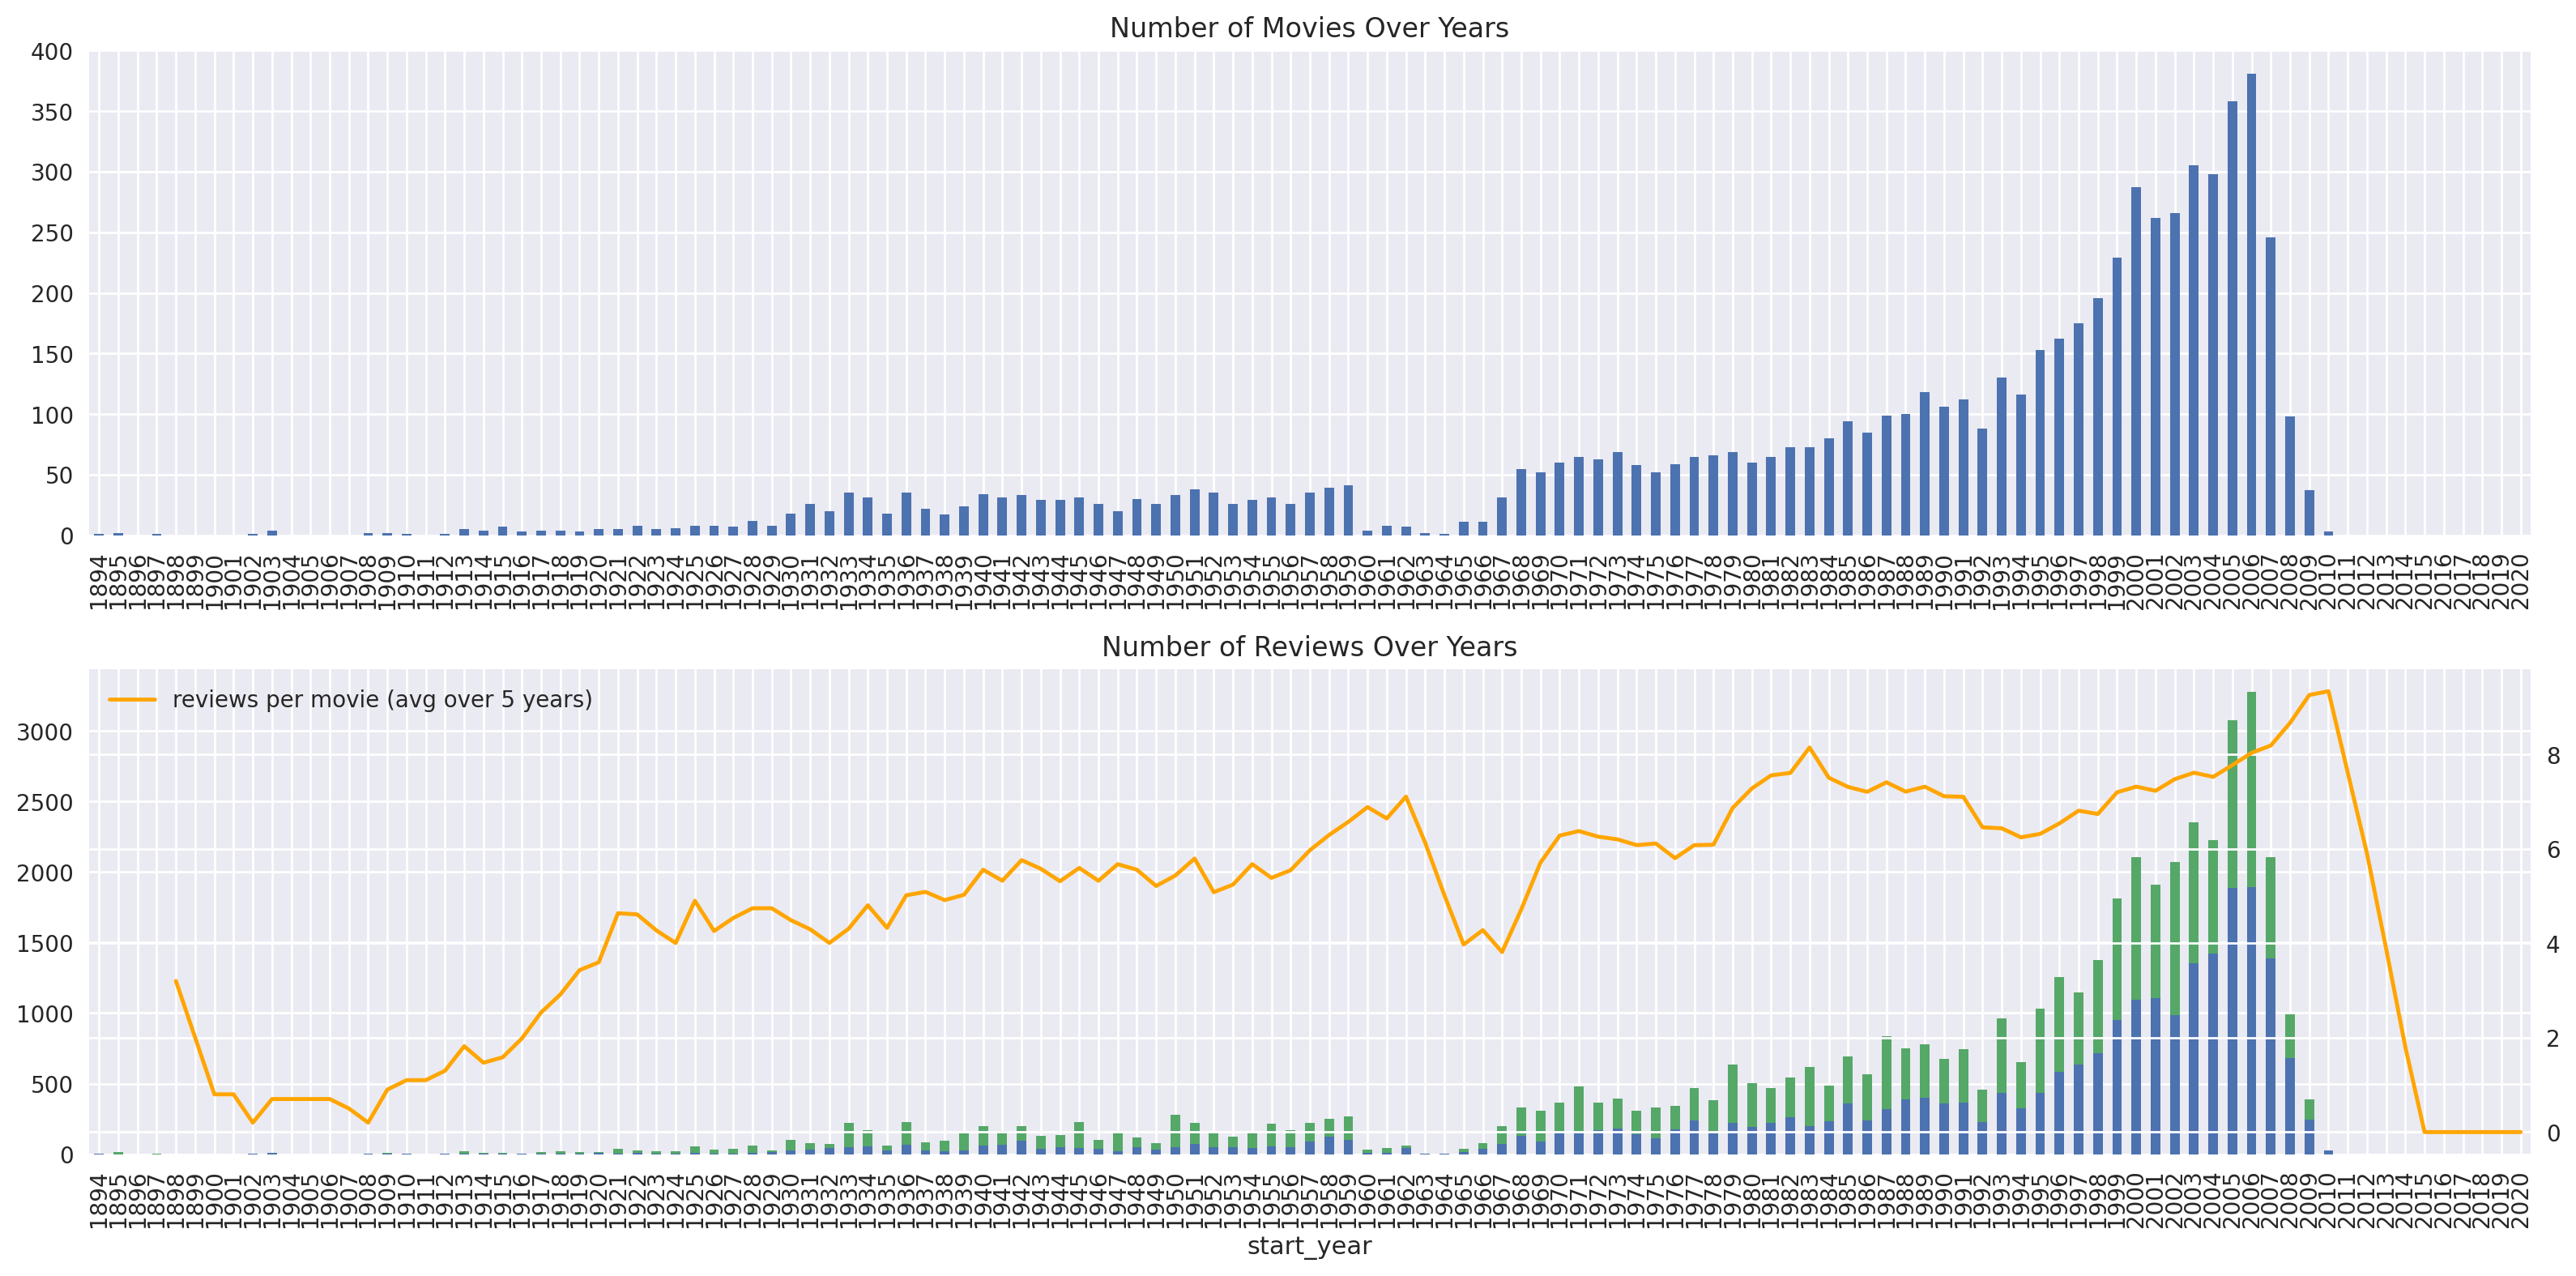

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Temporal Distribution of Movies and Reviews

The temporal analysis shows that the dataset spans a wide historical range of films, but the distribution is far from uniform across years. The number of movies represented in the corpus rises gradually over time and increases sharply in later decades, especially from the 1990s through the 2000s. This indicates that the dataset is more heavily populated with relatively recent titles than with older films.

A similar pattern is visible in the review counts. Both negative and positive reviews become much more frequent in later years, suggesting that the textual data is concentrated around modern movie releases and more recent audience activity. Importantly, the growth of both sentiment classes appears broadly parallel, which supports the earlier conclusion that the dataset is balanced with respect to polarity even if it is temporally uneven.

The rolling average of reviews per movie also increases over time, implying that newer films in the dataset tend to attract more review activity on average. This may influence the vocabulary and stylistic patterns learned by the models, since more recent reviews are likely to dominate the training signal. The decline in the final years of the timeline is most likely explained by incomplete coverage rather than a true reduction in movie production or audience engagement.

Overall, the dataset is temporally imbalanced but sentiment-balanced. This does not invalidate the classification task, but it is an important contextual finding: the model will primarily learn from review language associated with more recent films and review behavior.

</div>

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

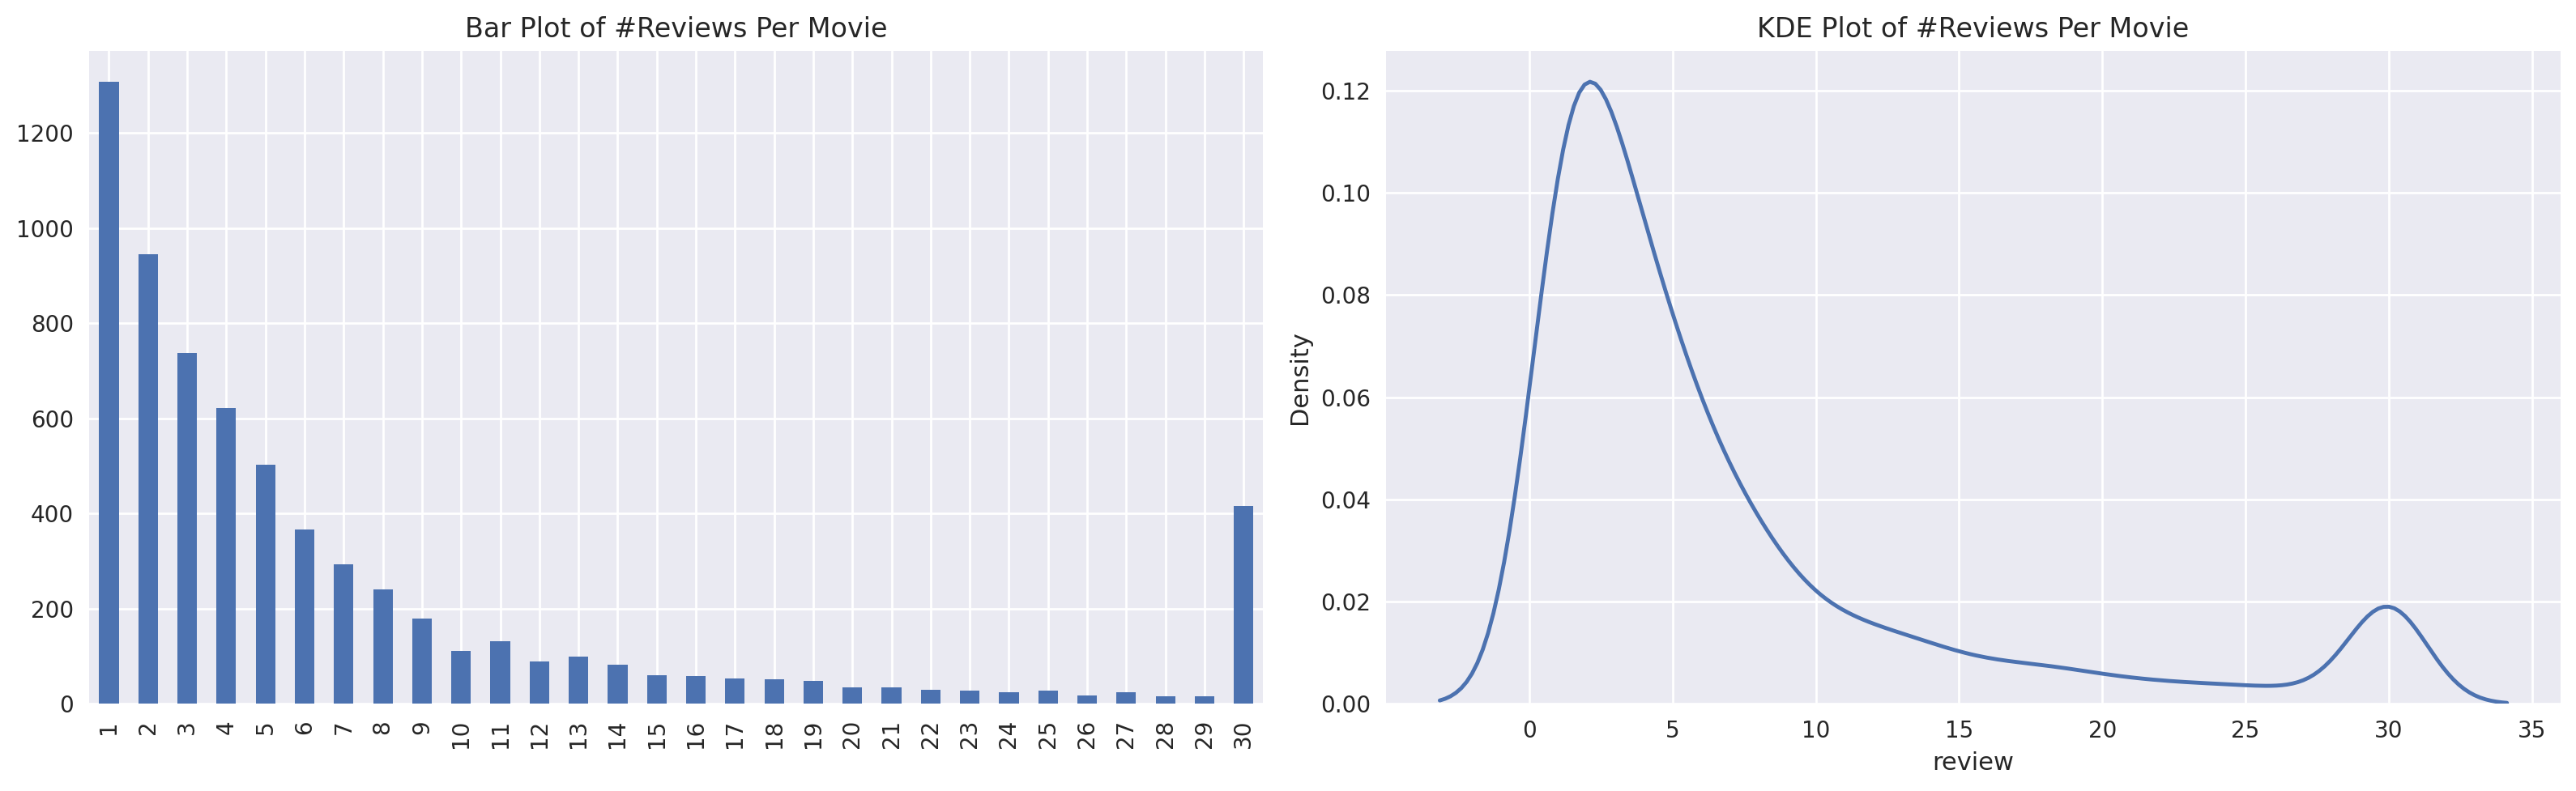

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Distribution of Reviews per Movie

The distribution of review counts per movie is clearly right-skewed. Most titles in the dataset are associated with only a small number of reviews, while a much smaller subset of movies accumulates substantially more review entries. This indicates that review activity is not evenly distributed across films, which is typical in user-generated datasets where a limited number of well-known or highly discussed titles attract disproportionate attention.

The bar plot provides the most direct view of this pattern because the underlying variable is a discrete count. The KDE plot supports the same general conclusion, although it should be interpreted more cautiously since kernel density estimation smooths the data and may hide some of the exact frequency structure. A noticeable concentration near the upper boundary of the distribution suggests that some titles repeatedly reach the highest observed review-count range in this dataset.

From a modeling perspective, this result means that certain movies contribute more textual data than others, which may amplify recurring vocabulary, sentiment phrasing, or topic-specific expressions linked to popular titles. However, this does not indicate a problem with sentiment balance itself. Rather, it reflects uneven review coverage at the movie level, which is an expected characteristic of real-world review corpora.

</div>

In [11]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

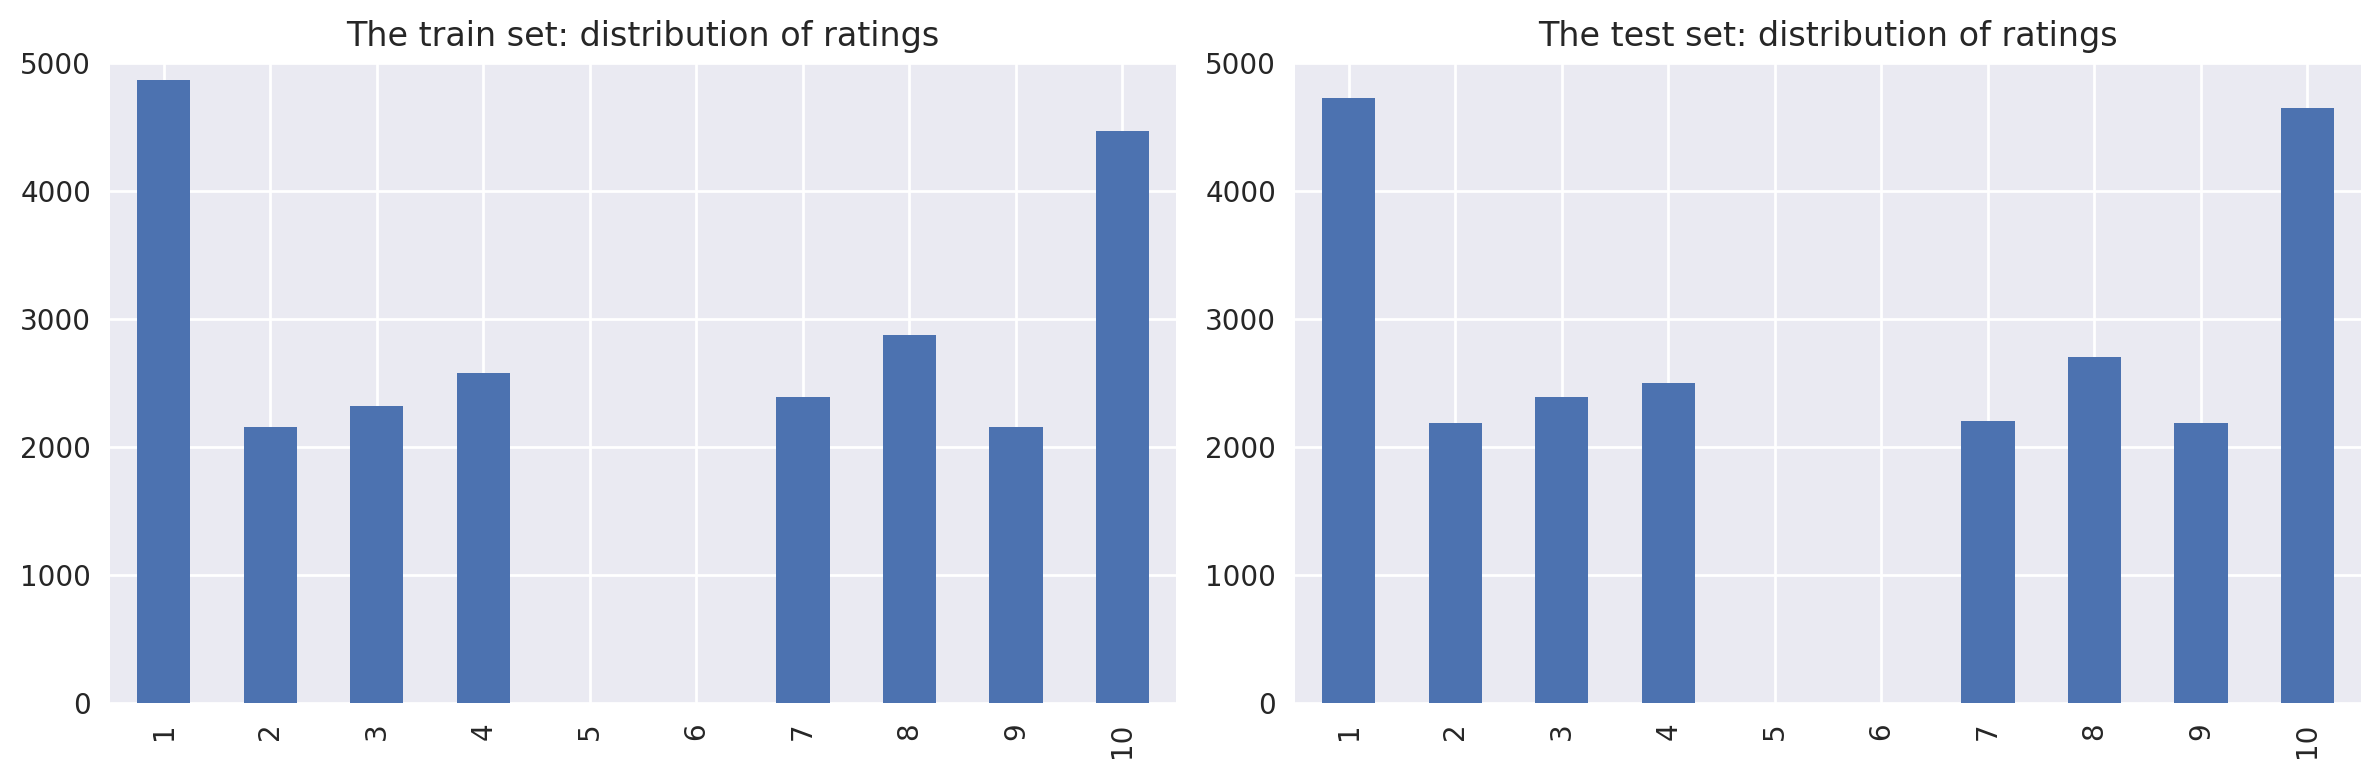

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Distribution of Ratings Across Train and Test Sets

The rating distributions in the training and test sets are highly consistent, which indicates that the predefined split preserves the overall structure of the dataset. This is an important finding because it means that model performance on the test set will be evaluated on data that is distributed similarly to the data used for training, reducing the likelihood of artificial performance shifts caused by sampling differences.

A second notable pattern is the strong concentration of observations at the extreme ends of the rating scale, particularly at ratings 1 and 10. In contrast, middle-range values are much less frequent, and ratings 5 and 6 are absent altogether. This suggests that the dataset is intentionally focused on polarized opinions rather than neutral or borderline reviews. As a result, the sentiment classification task is structured around distinguishing clearly negative reviews from clearly positive ones.

From a modeling perspective, this is beneficial because it makes the binary classification objective more well-defined. At the same time, it should be acknowledged that the model will not learn to handle genuinely neutral sentiment, since such examples are not represented in the data. Overall, the distributions confirm that the dataset is balanced, internally consistent, and well aligned with the project’s objective of polarity classification.

</div>

Distribution of negative and positive reviews over the years for two parts of the dataset

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


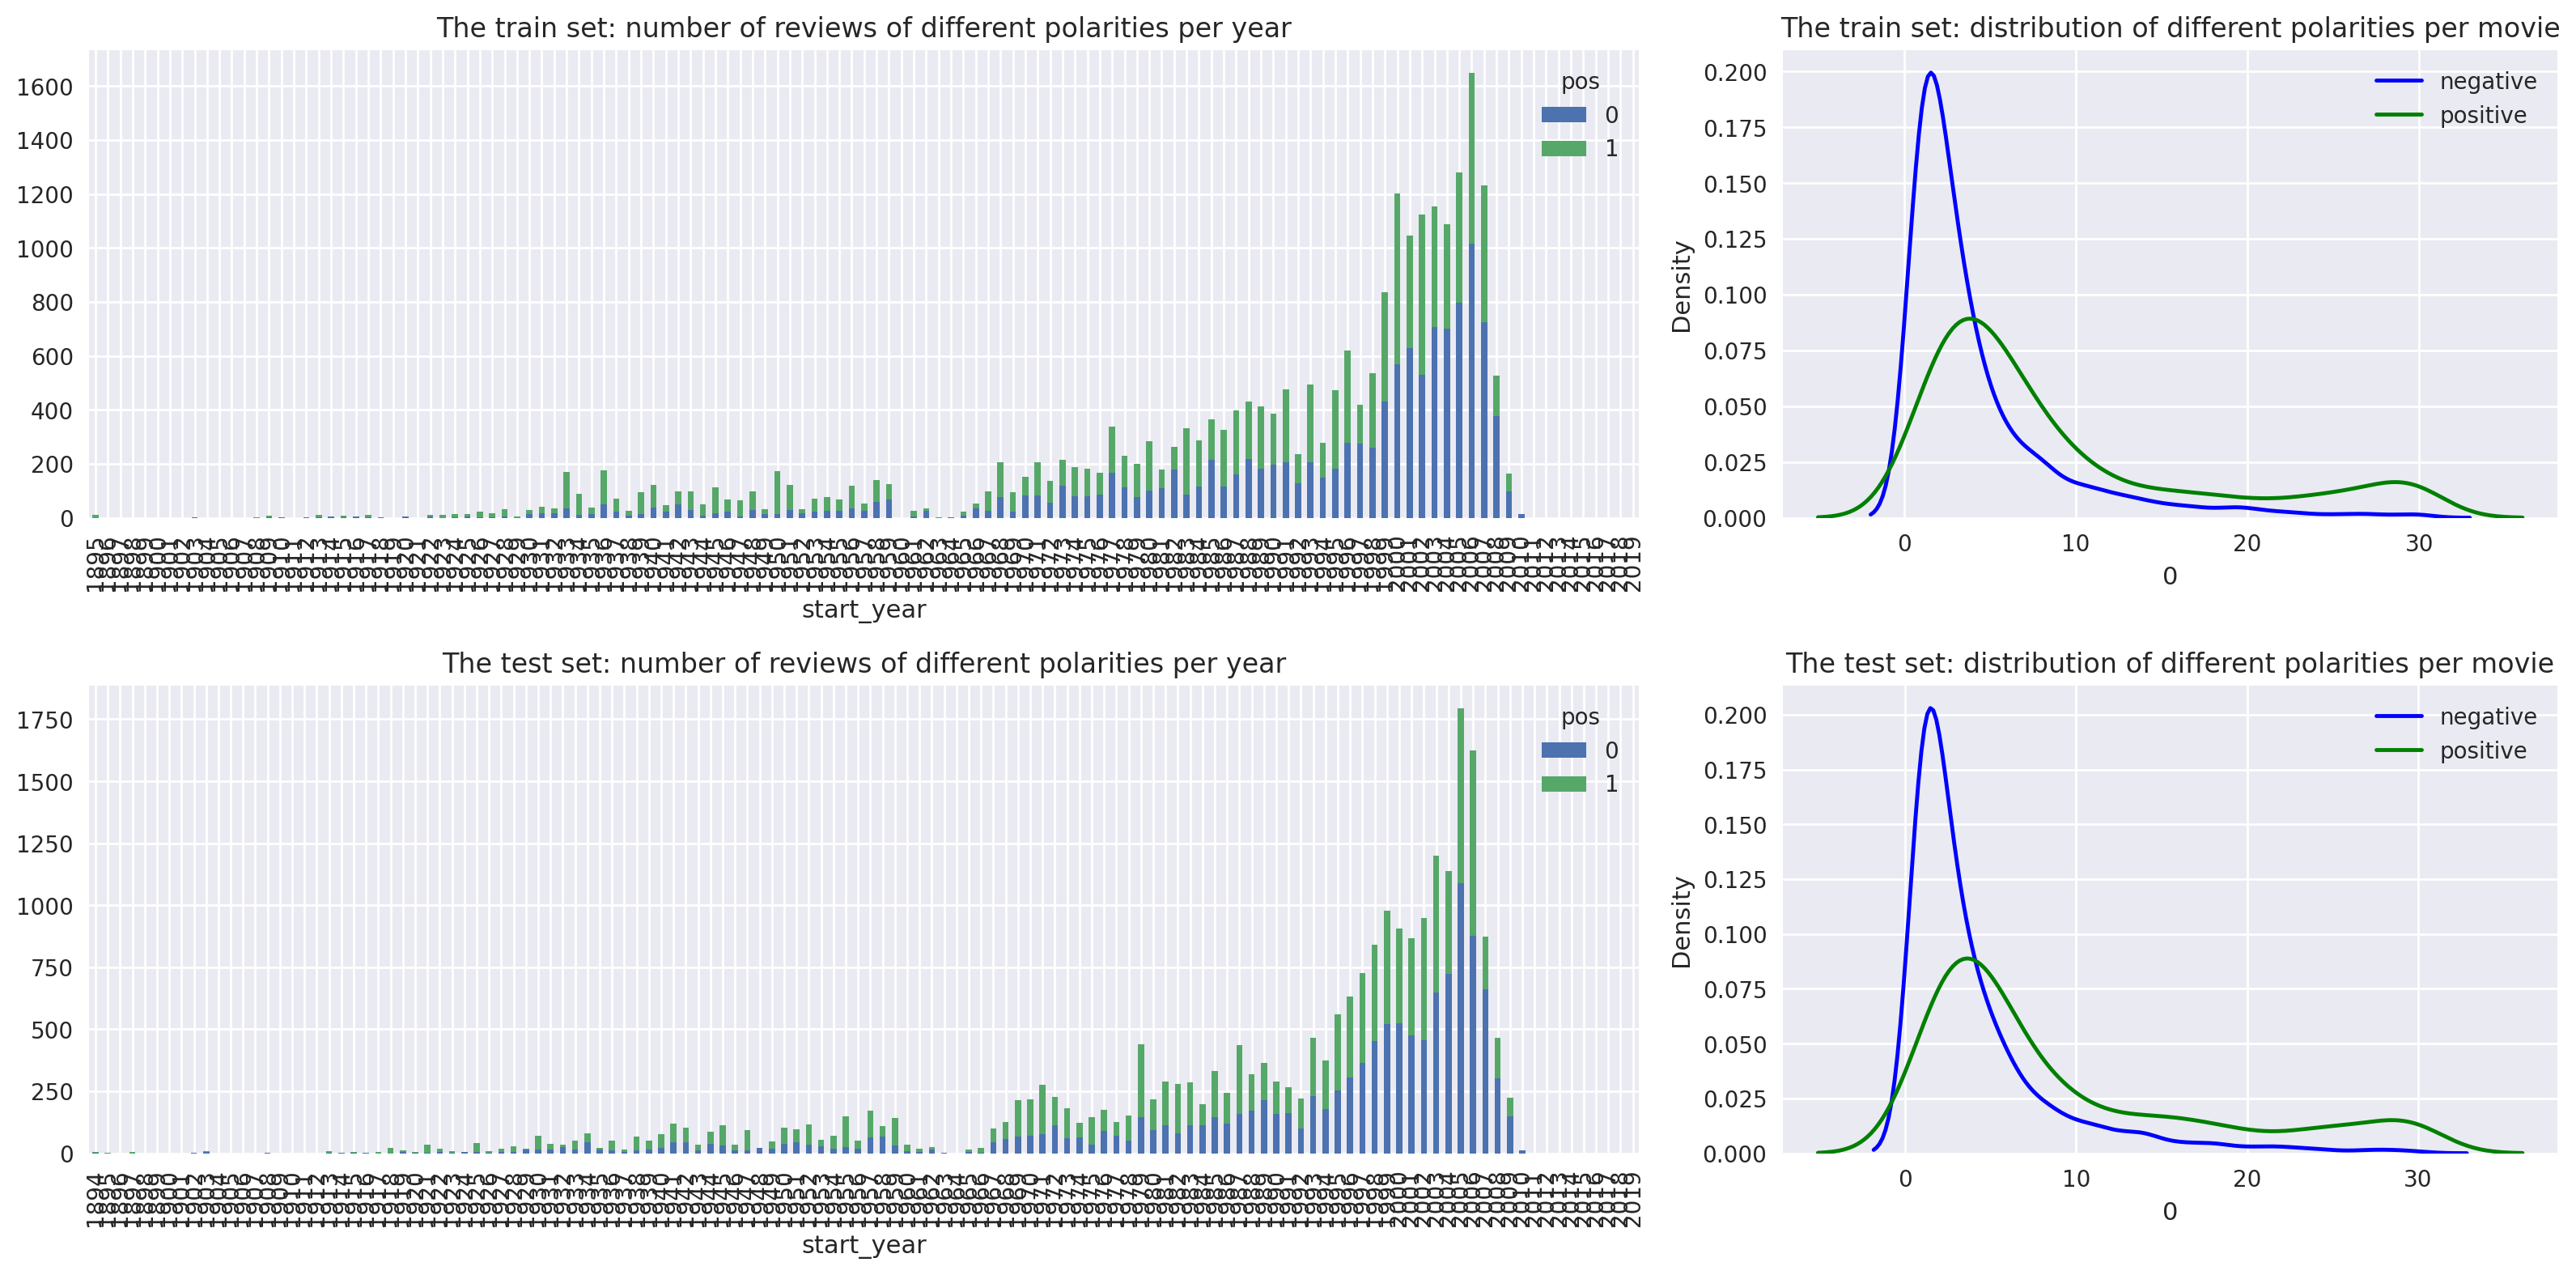

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Polarity Distribution Over Time and Across Movies

The train and test subsets display very similar polarity patterns over time, which supports the consistency of the predefined split. In both parts of the dataset, the number of positive and negative reviews increases substantially in later years, especially for more recent films. This confirms that the dataset is temporally concentrated in modern periods, while still maintaining a broadly balanced sentiment structure.

The density plots of review counts per movie suggest a mild difference between the two sentiment classes. Negative reviews are more sharply concentrated around lower review frequencies, whereas positive reviews appear more broadly distributed and extend further into higher review-count regions. This indicates that movies associated with positive reviews may, on average, receive a wider spread of review activity. However, the difference is not large enough to suggest any problematic skew in the target distribution.

Overall, the train and test sets remain well aligned in both temporal structure and polarity composition. This is a positive sign for downstream modeling, since it suggests that evaluation results will reflect genuine model generalization rather than differences in dataset composition.

</div>

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [14]:

import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Evaluation Procedure

To ensure consistent model comparison, a unified evaluation function was prepared for all classifiers in the project. This routine assesses model performance on both the training and test sets using several complementary metrics, including Accuracy, F1 score, Average Precision Score, and ROC AUC. Since the project requirement is centered on F1 score, this metric will serve as the primary basis for judging model success.

In addition to numerical metrics, the routine visualizes F1 across classification thresholds, along with ROC and precision-recall curves. This provides a broader view of classifier behavior and helps identify whether a model is robust across probability cutoffs rather than only at the default decision threshold. As a result, the evaluation framework supports both formal comparison and deeper diagnostic interpretation of model quality.

</div>

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [15]:
df_reviews['review_norm'] = (
    df_reviews['review']
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [16]:
display(df_reviews[['review', 'review_norm']].head())

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i m totally agree with garryjohal from singapo...


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Text Normalization

A normalized review column was created to prepare the text for vectorization and model training. The preprocessing pipeline converts all text to lowercase, removes digits and punctuation, and standardizes whitespace. This reduces superficial variation in the corpus and helps ensure that tokens with the same semantic meaning are treated consistently during feature extraction.

The normalized examples confirm that the transformation behaves as expected. While contractions are simplified during punctuation removal, this level of normalization is appropriate for classical text modeling approaches such as TF-IDF with linear classifiers. The original review text is preserved separately, which is useful for interpretation and for testing custom review predictions later in the project.

</div>

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [17]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy().reset_index(drop=True)
df_reviews_test = df_reviews.query('ds_part == "test"').copy().reset_index(drop=True)

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print("Train shape:", df_reviews_train.shape)
print("Test shape:", df_reviews_test.shape)
print("Train target shape:", train_target.shape)
print("Test target shape:", test_target.shape)

Train shape: (23796, 20)
Test shape: (23535, 20)
Train target shape: (23796,)
Test target shape: (23535,)


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Train-Test Partitioning

The dataset already provides an explicit train-test split through the `ds_part` column, so no additional sampling or random partitioning was necessary. This is preferable for the project because it preserves the original evaluation design and ensures that all models are assessed on the same predefined holdout set.

After separating the data, the training subset contains 23,796 observations and the test subset contains 23,535 observations. The target variable was extracted from the `pos` column for both partitions, producing target vectors with matching dimensions. These results confirm that the split was applied correctly and that the feature and target data are aligned for downstream text vectorization and model training.

</div>

## Working with models

### Model 0 - Constant

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


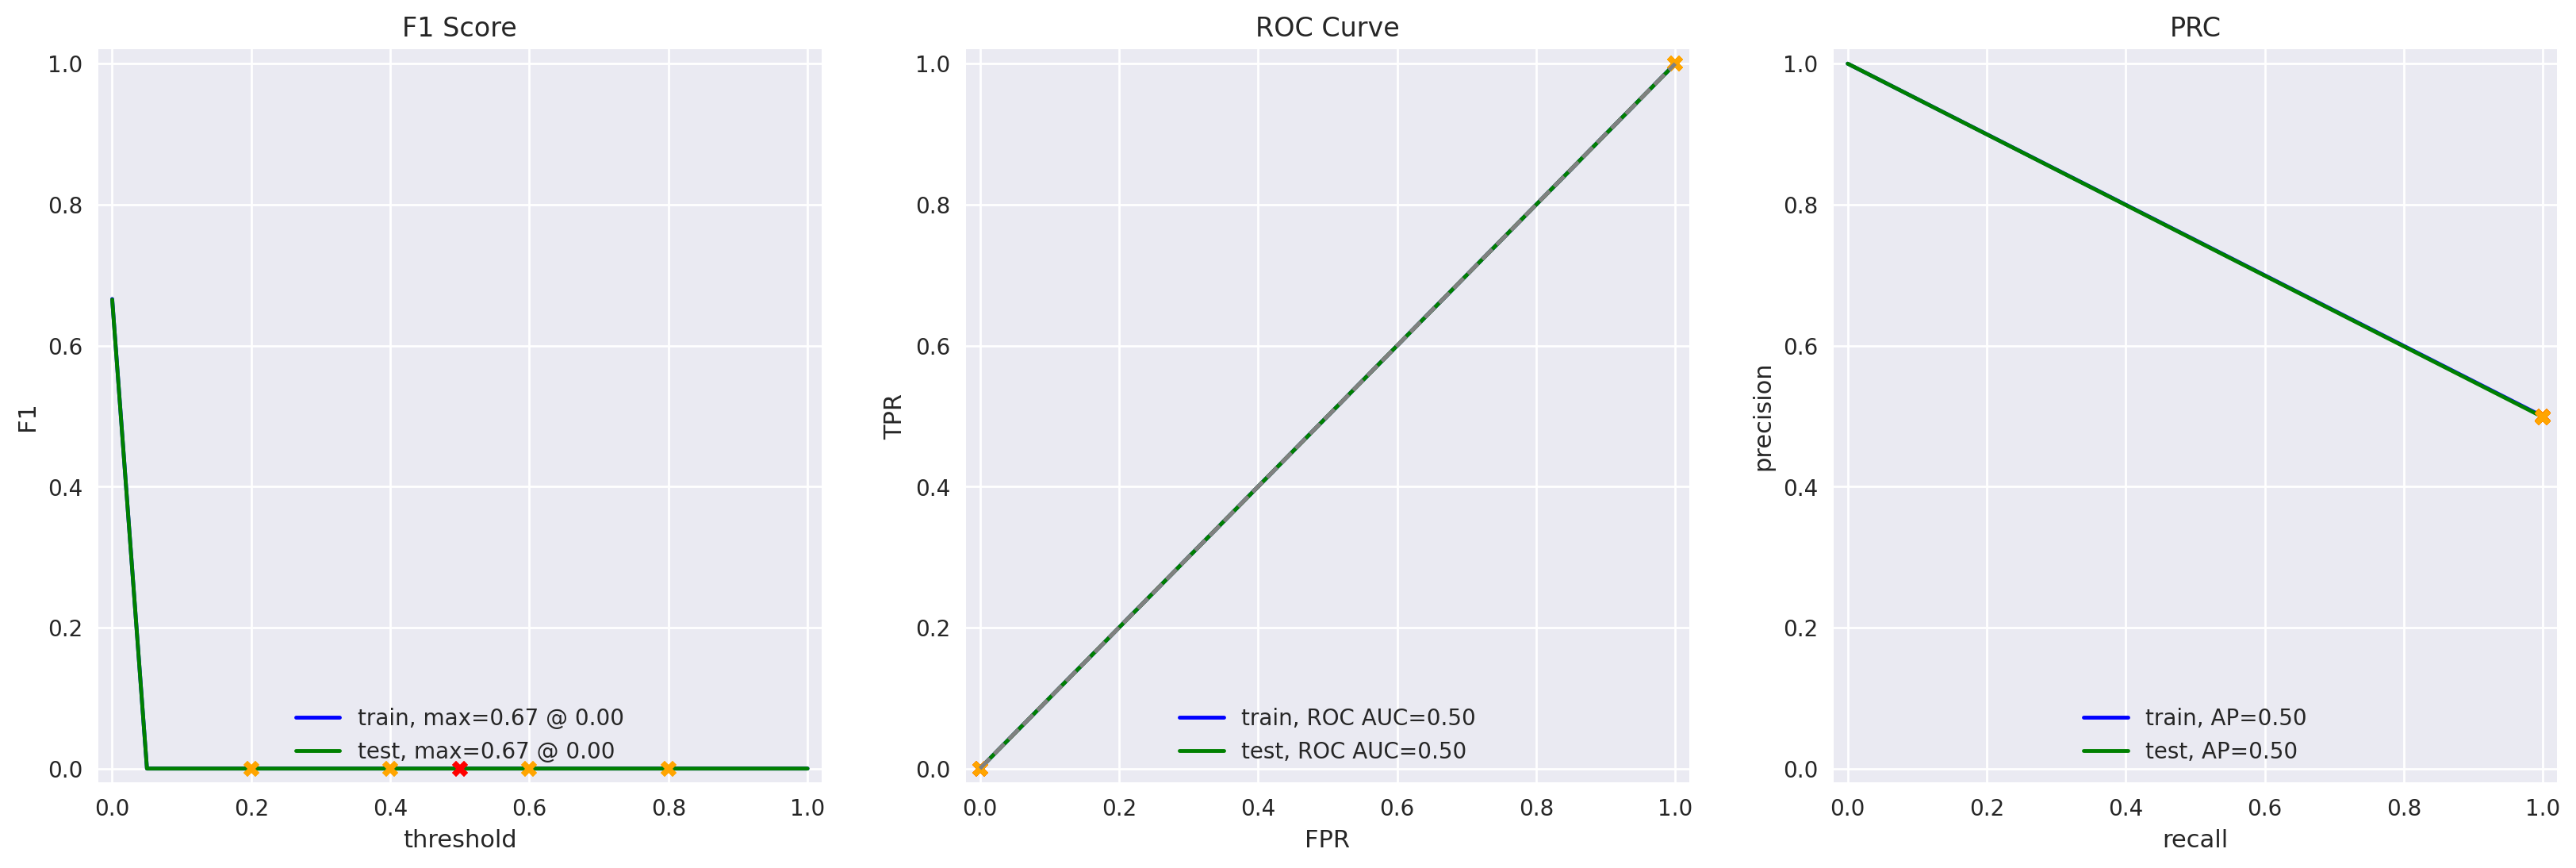

In [18]:
# Model 0 - Constant / Dummy baseline

from sklearn.dummy import DummyClassifier

# create a single non-informative feature for every review
train_features_0 = np.zeros((len(df_reviews_train), 1))
test_features_0 = np.zeros((len(df_reviews_test), 1))

# baseline model: always predicts the majority class from the training set
model_0 = DummyClassifier(strategy='most_frequent')

model_0.fit(train_features_0, train_target)

evaluate_model(model_0, train_features_0, train_target, test_features_0, test_target)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 0 Results: Dummy Baseline

The dummy classifier performs at chance level on both the training and test sets, with an accuracy of 0.50 and ROC AUC of 0.50. This is expected because the model does not use any textual information and simply predicts the most frequent class. As a result, it has no real ability to distinguish between positive and negative reviews.

The F1 score is 0.00 on both subsets, which indicates that the baseline fails to capture the positive class under the default prediction rule. This confirms that a non-informative classifier is not sufficient for the task and establishes a meaningful lower bound for comparison. Any successful text-based model should substantially exceed this baseline, particularly on the F1 metric required by the project.

</div>

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [19]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [20]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

tfidf_vectorizer_1 = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])

print("Train features shape:", train_features_1.shape)
print("Test features shape:", test_features_1.shape)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Train features shape: (23796, 329173)
Test features shape: (23535, 329173)


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 1 Feature Extraction: NLTK, TF-IDF

For the first text-based model, the normalized reviews were transformed into TF-IDF vectors using English stopword removal. The vectorizer was configured to capture both unigrams and bigrams, allowing the model to learn not only individual sentiment-bearing terms but also short phrases that often carry stronger polarity signals, such as negations and opinion expressions.

Additional constraints were applied through `min_df`, `max_df`, and `sublinear_tf` to reduce noise and improve feature quality. The resulting sparse matrices contain 329,173 features for both the training and test sets, reflecting a high-dimensional but standard representation for classical text classification. This feature space is suitable for linear models such as logistic regression, which typically perform strongly on sentiment tasks when paired with TF-IDF.

</div>

In [21]:
model_1 = LogisticRegression(
    max_iter=1000,
    random_state=12345
)

model_1.fit(train_features_1, train_target)

LogisticRegression(max_iter=1000, random_state=12345)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 1 Training: Logistic Regression

A logistic regression classifier was trained on the TF-IDF representation of the review text. This model is a strong baseline for sentiment analysis because it handles high-dimensional sparse text features efficiently and often provides highly competitive results on binary classification tasks.

The maximum iteration limit was increased to ensure stable convergence on the large feature space, while a fixed random state was used to preserve reproducibility. Since logistic regression estimates class probabilities directly, it also integrates well with the evaluation framework used in this project, including F1, ROC AUC, and precision-recall analysis.

</div>

          train  test
Accuracy   0.96  0.89
F1         0.96  0.89
APS        0.99  0.95
ROC AUC    0.99  0.96


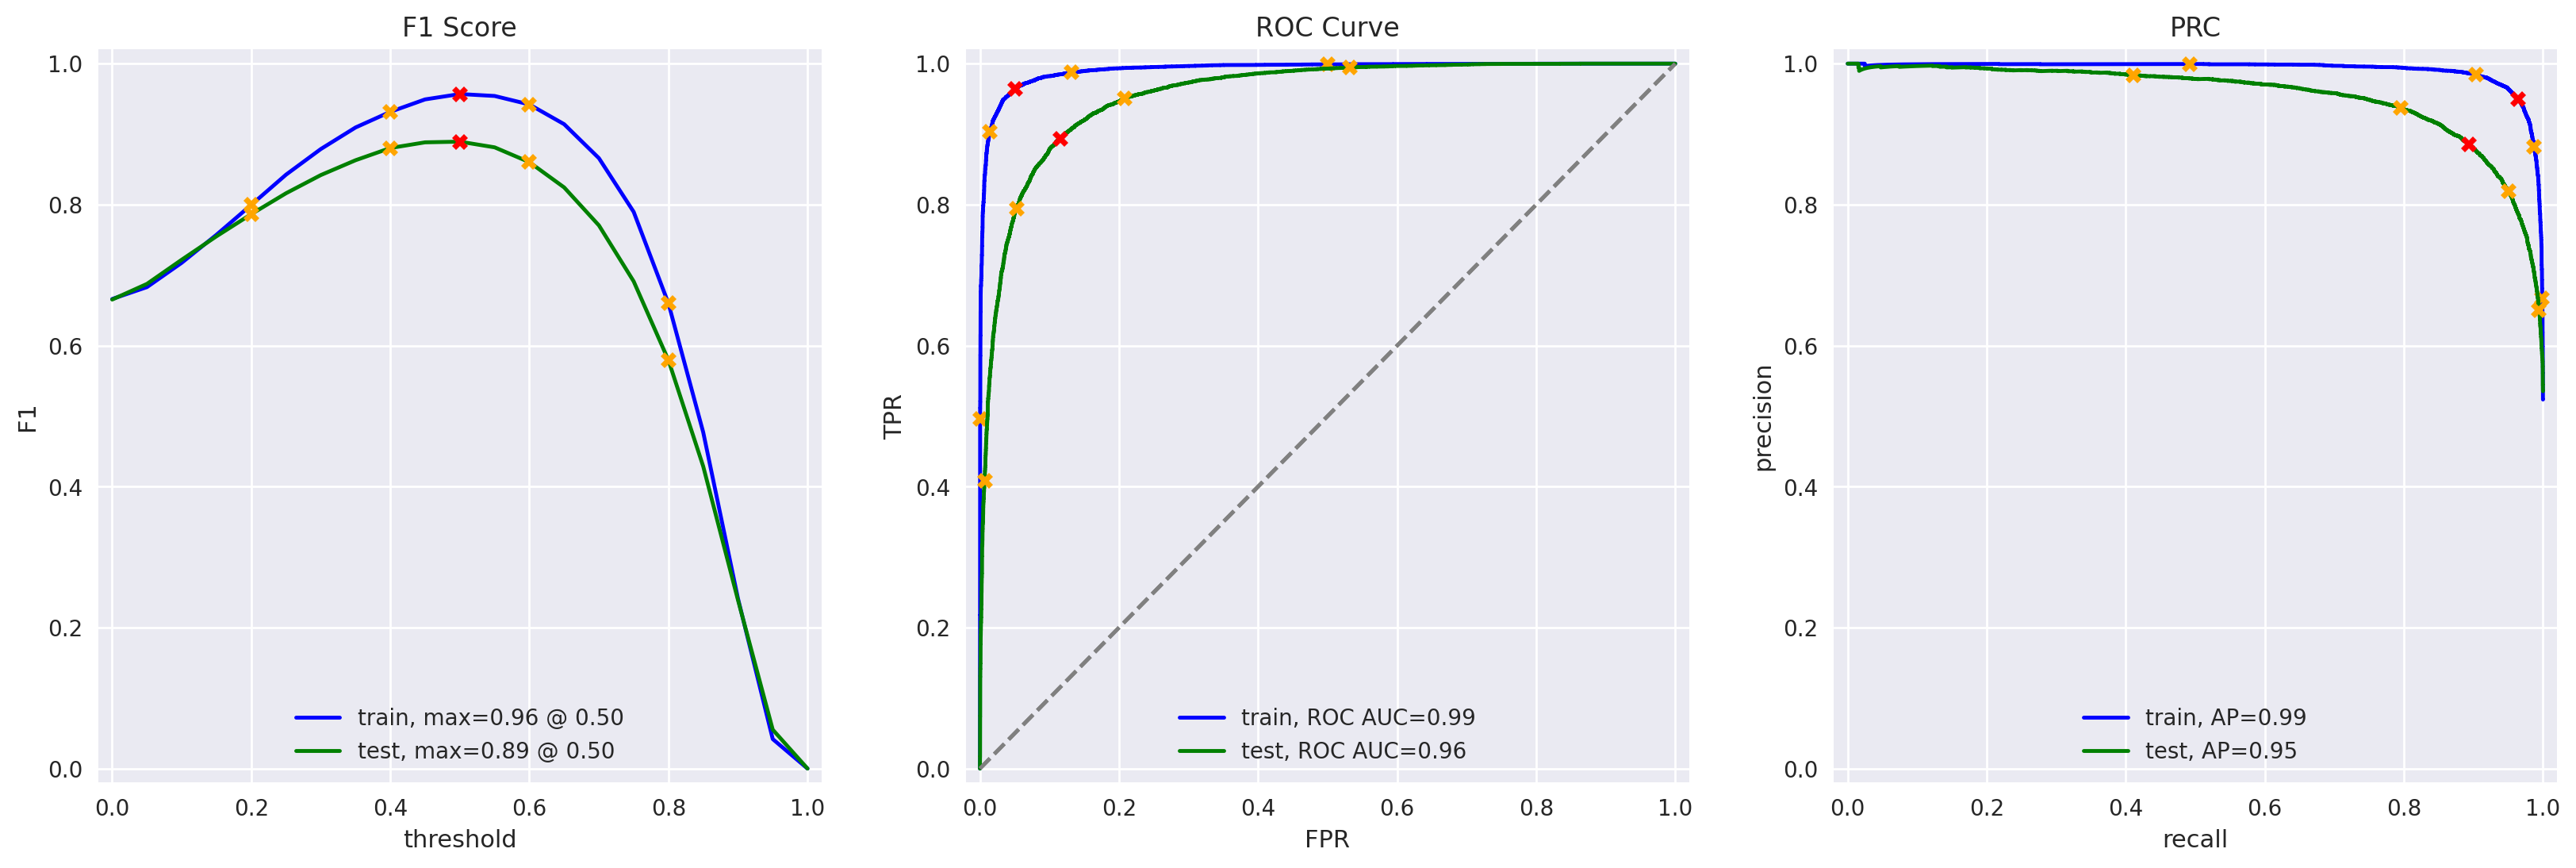

In [22]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 1 Results: NLTK + TF-IDF + Logistic Regression

The first text-based model delivers strong performance on both the training and test sets. On the test set, the logistic regression classifier achieved an F1 score of 0.89, which exceeds the project requirement of 0.85. It also produced a test accuracy of 0.89, an average precision score of 0.95, and a ROC AUC of 0.96, indicating that the model is highly effective at distinguishing between positive and negative reviews.

The training metrics are higher than the testing metrics, which suggests a moderate degree of overfitting. However, the gap is not unusually large for a high-dimensional TF-IDF representation, and the model still generalizes well to unseen data. The F1 curve also peaks near the default decision threshold of 0.50, showing that the classifier is well calibrated for standard binary prediction.

Overall, this model establishes a strong benchmark for the project. It confirms that a classical TF-IDF representation combined with logistic regression is highly effective for sentiment classification on this dataset.

</div>

### Model 3 - spaCy, TF-IDF and LR

In [23]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [24]:
# Lightweight spaCy preprocessing: tokenizer + stopword filtering only
def preprocess_texts_spacy_light(texts, batch_size=1000):
    processed_texts = []

    for doc in nlp.tokenizer.pipe(texts.astype(str), batch_size=batch_size):
        tokens = [
            token.lower_
            for token in doc
            if token.is_alpha and not token.is_stop
        ]
        processed_texts.append(' '.join(tokens))

    return processed_texts

df_reviews_train['review_norm_3'] = preprocess_texts_spacy_light(df_reviews_train['review'])
df_reviews_test['review_norm_3'] = preprocess_texts_spacy_light(df_reviews_test['review'])

display(df_reviews_train[['review', 'review_norm_3']].head())

,review,review_norm_3
0,The pakage implies that Warren Beatty and Gold...,pakage implies warren beatty goldie hawn pulli...
1,How the hell did they get this made?! Presenti...,hell presenting caper comedy misbegotten essen...
2,This true story of Carlson's Raiders is more o...,true story carlson raiders army training film ...
3,Should have been titled 'Balderdash!' Little i...,titled balderdash little film true island fact...
4,The movie 'Gung Ho!': The Story of Carlson's M...,movie gung ho story carlson makin island raide...


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 3 Preprocessing Strategy: Lightweight spaCy Tokenization

For the third model, spaCy is used in a lightweight preprocessing configuration focused on tokenization and stopword filtering rather than full lemmatization. This approach breaks each review into tokens, keeps only alphabetic terms, converts them to lowercase, and removes common stopwords. The result is a cleaner text representation that reduces noise while remaining computationally efficient for a large corpus.

Compared with the earlier normalization pipeline, this method relies on spaCy’s tokenizer and linguistic token attributes to produce a more structured filtering process. At the same time, it avoids the heavier processing cost of full lemmatization, which makes it more practical in the notebook environment. The cleaned text is then used as the input for TF-IDF vectorization and logistic regression, allowing direct comparison with Model 1 under a different preprocessing strategy.

</div>

In [25]:
display(df_reviews_train[['review', 'review_norm_3']].head())
display(df_reviews_test[['review', 'review_norm_3']].head())

display(df_reviews_train[['review', 'review_norm_3']].head())

,review,review_norm_3
0,The pakage implies that Warren Beatty and Gold...,pakage implies warren beatty goldie hawn pulli...
1,How the hell did they get this made?! Presenti...,hell presenting caper comedy misbegotten essen...
2,This true story of Carlson's Raiders is more o...,true story carlson raiders army training film ...
3,Should have been titled 'Balderdash!' Little i...,titled balderdash little film true island fact...
4,The movie 'Gung Ho!': The Story of Carlson's M...,movie gung ho story carlson makin island raide...


,review,review_norm_3
0,There is no real story the film seems more lik...,real story film like fly wall drama documentar...
1,Um .... a serious film about troubled teens in...,um film troubled teens singapore country knowl...
2,I'm totally agree with GarryJohal from Singapo...,totally agree garryjohal singapore comments fi...
3,This is the first movie I've seen from Singapo...,movie seen singapore great know lot asia langu...
4,Yes non-Singaporean's can't see what's the big...,yes non singaporean big deal film references f...


,review,review_norm_3
0,The pakage implies that Warren Beatty and Gold...,pakage implies warren beatty goldie hawn pulli...
1,How the hell did they get this made?! Presenti...,hell presenting caper comedy misbegotten essen...
2,This true story of Carlson's Raiders is more o...,true story carlson raiders army training film ...
3,Should have been titled 'Balderdash!' Little i...,titled balderdash little film true island fact...
4,The movie 'Gung Ho!': The Story of Carlson's M...,movie gung ho story carlson makin island raide...


In [26]:
tfidf_vectorizer_3 = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

train_features_3 = tfidf_vectorizer_3.fit_transform(df_reviews_train['review_norm_3'])
test_features_3 = tfidf_vectorizer_3.transform(df_reviews_test['review_norm_3'])

print("Train features shape:", train_features_3.shape)
print("Test features shape:", test_features_3.shape)

Train features shape: (23796, 280408)
Test features shape: (23535, 280408)


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 3 Feature Extraction: TF-IDF Representation

The spaCy-processed reviews were converted into TF-IDF vectors using unigram and bigram features. The resulting sparse matrices contain 280,408 features for both the training and test sets. This feature count is lower than the one produced in Model 1, which is consistent with the lighter spaCy filtering step that removes stopwords and non-alphabetic tokens before vectorization.

A reduced feature space can be beneficial because it lowers dimensional noise while preserving sentiment-relevant terms and short phrases. This representation is still sufficiently expressive for a linear classifier and allows a fair comparison with the earlier TF-IDF-based logistic regression model under a different preprocessing strategy.

</div>

In [27]:
model_3 = LogisticRegression(
    max_iter=1000,
    random_state=12345
)

model_3.fit(train_features_3, train_target)

LogisticRegression(max_iter=1000, random_state=12345)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 3 Training: Logistic Regression

A logistic regression classifier was trained on the TF-IDF representation derived from the lightweight spaCy preprocessing pipeline. This model remains well suited to sparse, high-dimensional text data and provides a consistent basis for comparison with Model 1, since both models use the same classifier family but differ in how the review text is prepared before vectorization.

The training process completed successfully with an increased iteration limit to support convergence over the large feature space. This ensures that the model parameters were estimated under stable optimization conditions and can now be evaluated against the project’s performance target.

</div>

          train  test
Accuracy   0.95  0.88
F1         0.95  0.88
APS        0.99  0.95
ROC AUC    0.99  0.95


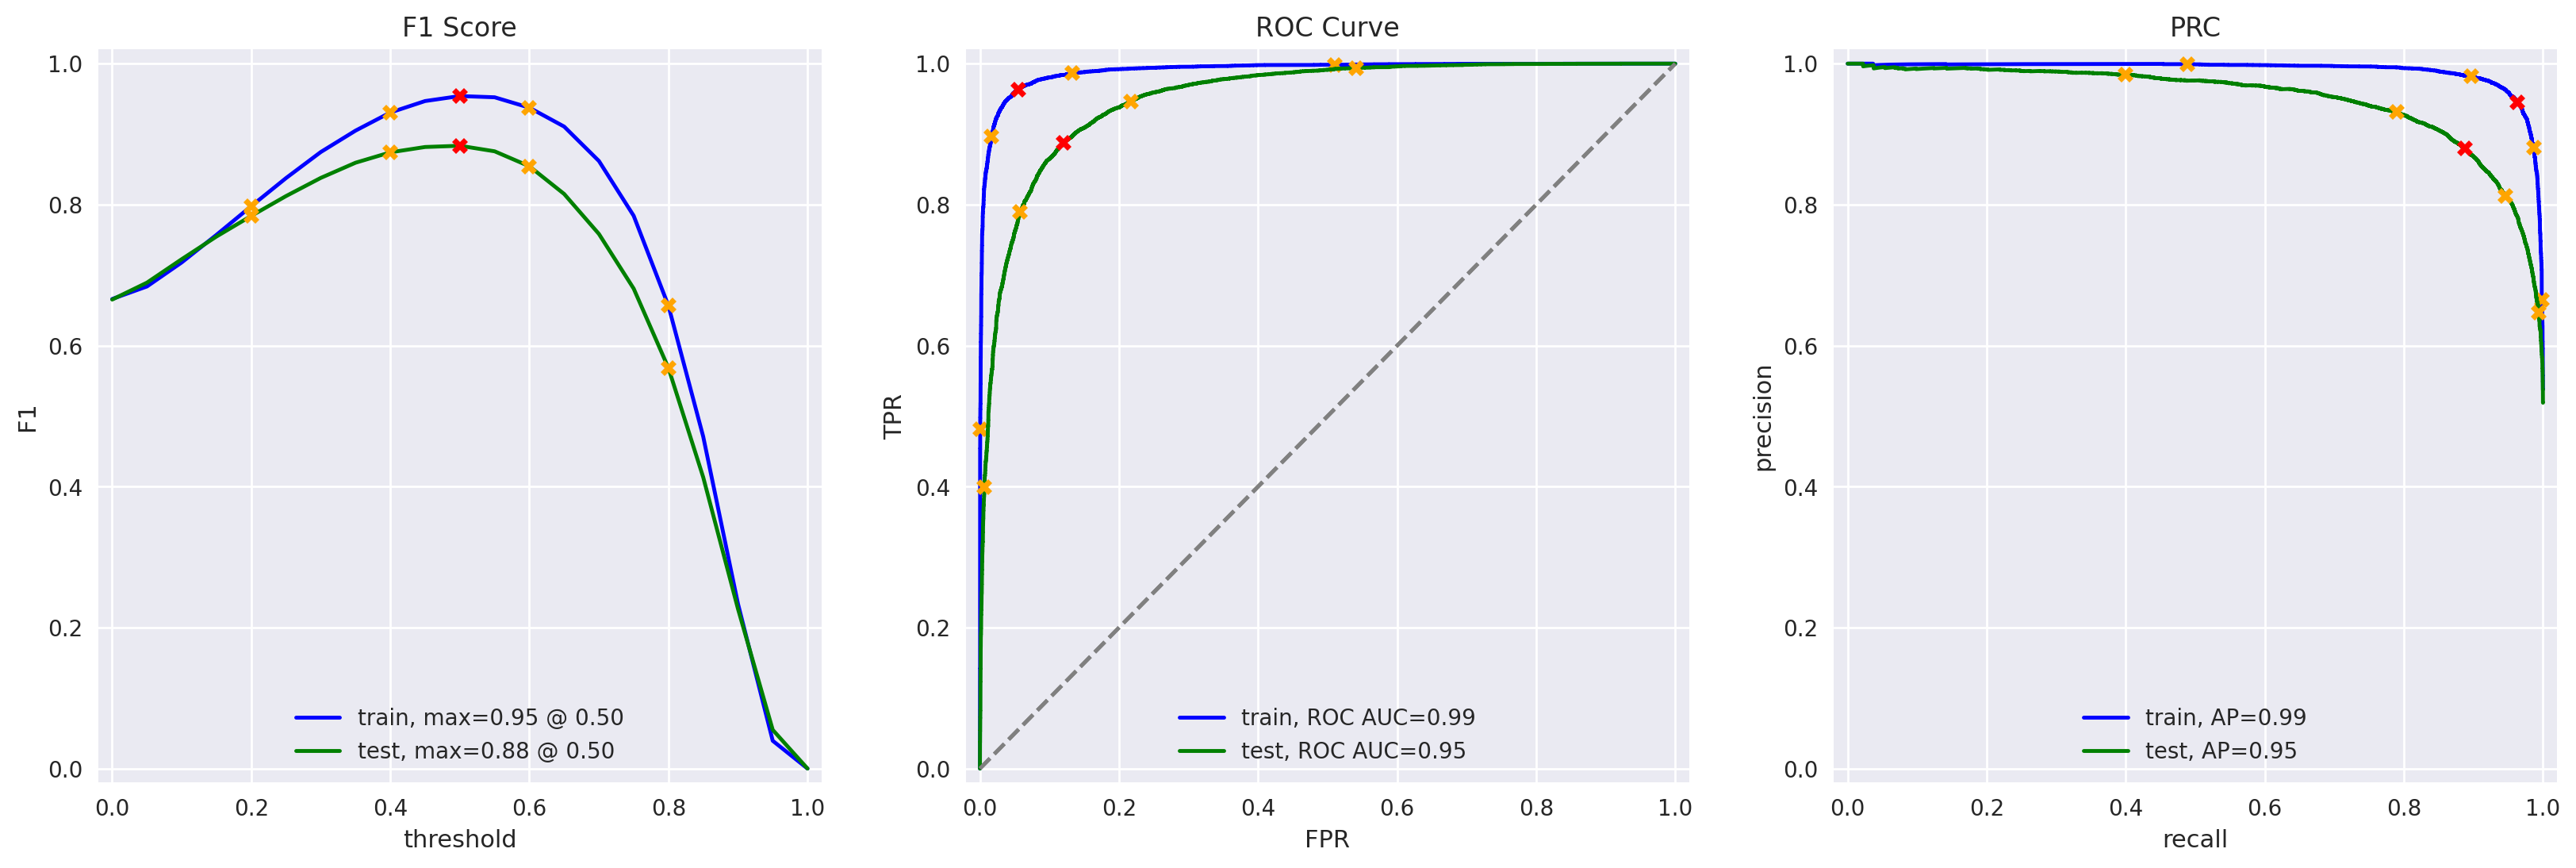

In [28]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 3 Results: spaCy-Light + TF-IDF + Logistic Regression

Model 3 achieved strong performance on both the training and test sets. On the test data, it reached an F1 score of 0.88, which exceeds the project requirement of 0.85 and confirms that the lightweight spaCy preprocessing pipeline is effective for sentiment classification. The model also achieved a test accuracy of 0.88, an average precision score of 0.95, and a ROC AUC of 0.95, indicating strong overall separability between positive and negative reviews.

Compared with Model 1, this model performs slightly worse on the test set, despite using a more structured preprocessing pipeline. This suggests that the simpler normalization strategy from Model 1 preserved enough useful lexical information to outperform the more aggressively filtered spaCy-based representation. In other words, the additional preprocessing did not translate into better classification quality for this dataset.

Overall, Model 3 remains a successful and competitive classifier, but it does not surpass the benchmark established by the NLTK-based TF-IDF and logistic regression approach. This makes Model 1 the stronger candidate at this stage, while Model 3 serves as a useful comparison showing that more sophisticated preprocessing does not necessarily guarantee better results.

</div>

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [29]:
from lightgbm import LGBMClassifier

In [30]:
model_4 = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    random_state=12345,
    verbose=-1
)

model_4.fit(train_features_3, train_target)

LGBMClassifier(n_estimators=200, random_state=12345, verbose=-1)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 4 Training: LightGBM Classifier

For the fourth model, a LightGBM classifier was trained on the same TF-IDF feature representation used in Model 3. This setup allows the effect of the classifier itself to be tested while holding the text preprocessing and vectorization pipeline constant. LightGBM is a gradient boosting method designed to model more complex decision boundaries than a standard linear classifier.

The model was trained successfully using the spaCy-light TF-IDF feature matrix. With this step complete, the next stage is to evaluate whether a boosting-based approach can improve sentiment classification performance relative to logistic regression on the same text representation.

</div>

          train  test
Accuracy   0.95  0.87
F1         0.95  0.87
APS        0.99  0.94
ROC AUC    0.99  0.94


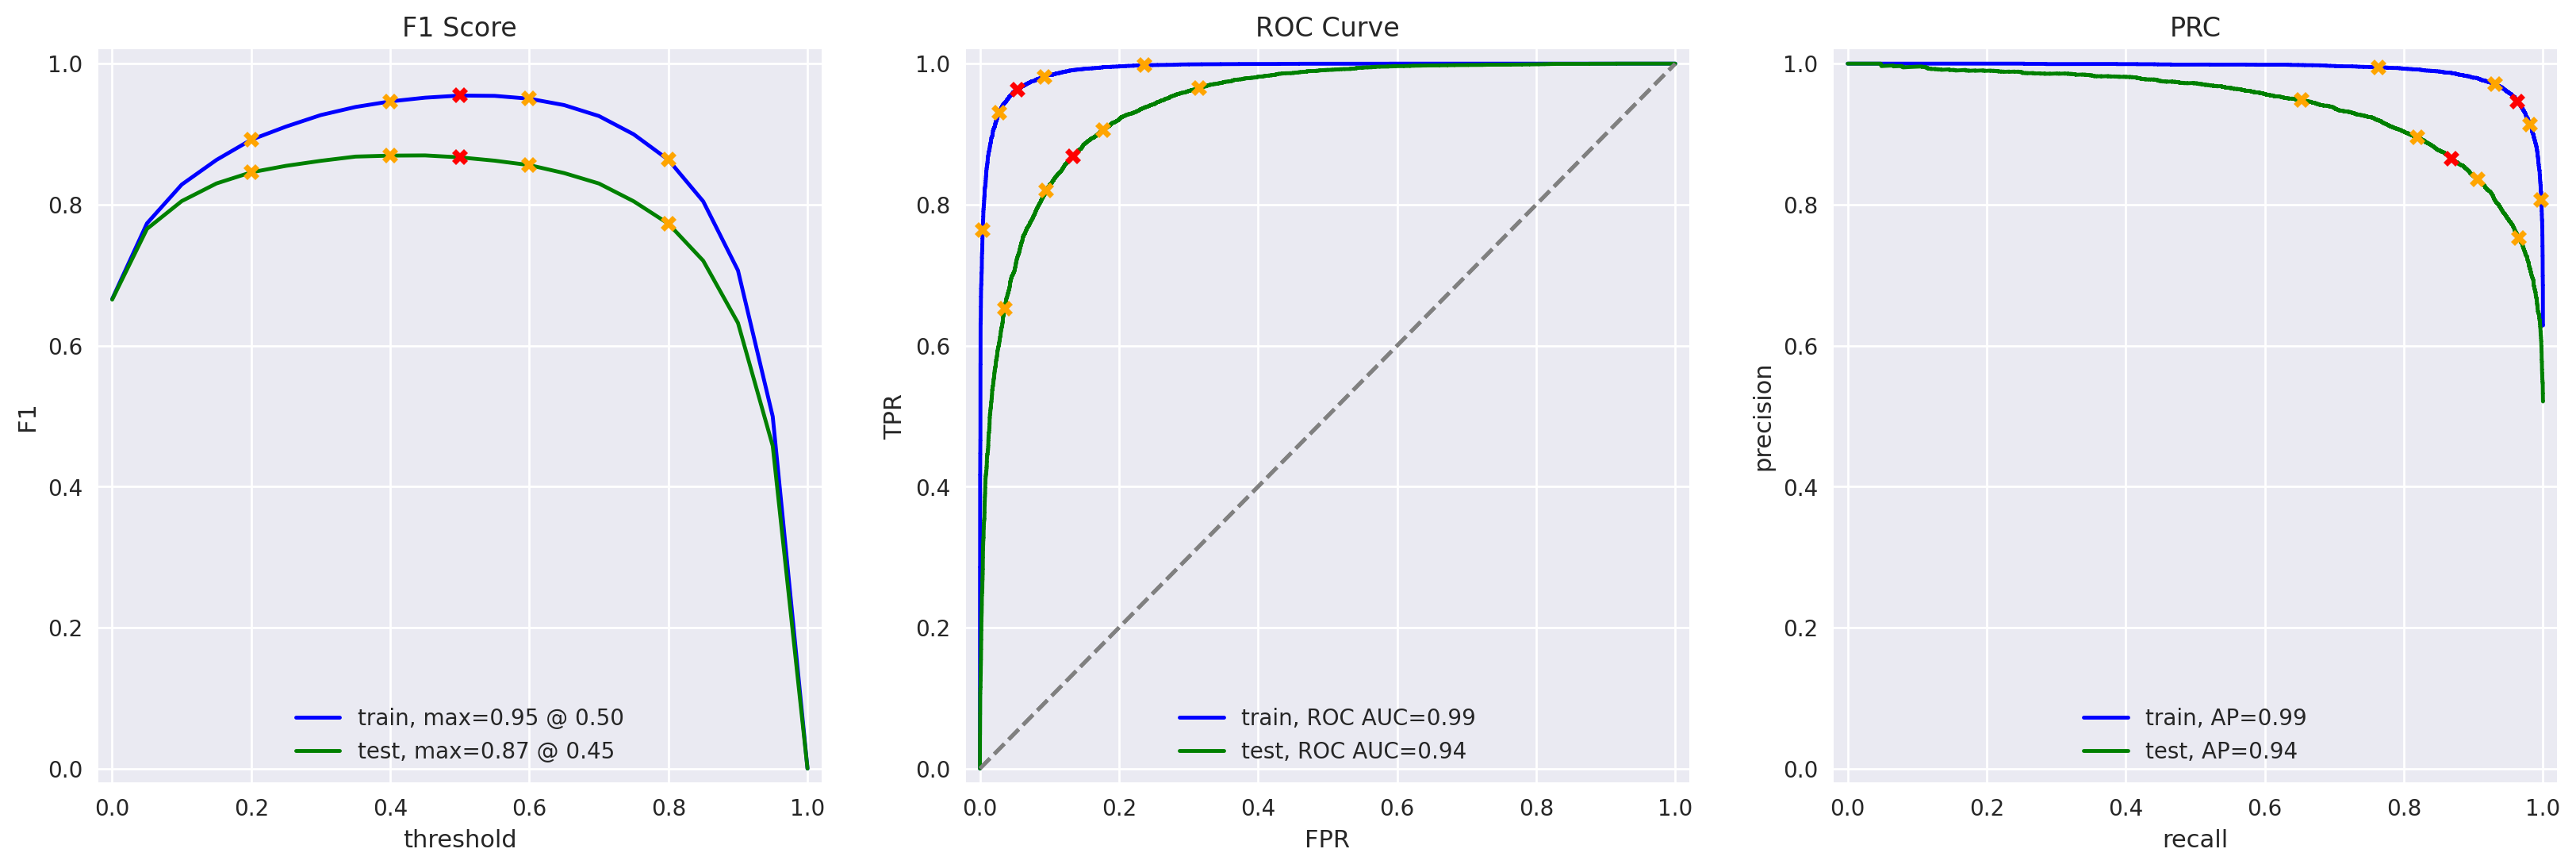

In [31]:
evaluate_model(model_4, train_features_3, train_target, test_features_3, test_target)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 4 Results: spaCy-Light + TF-IDF + LightGBM

Model 4 achieved a test F1 score of 0.87, which exceeds the project requirement of 0.85 and confirms that the model is capable of classifying sentiment effectively. It also produced a test accuracy of 0.87, an average precision score of 0.94, and a ROC AUC of 0.94. These results indicate strong classification performance overall, although the model is slightly less effective than the logistic regression alternatives tested earlier.

When compared directly with Models 1 and 3, the LightGBM classifier does not provide a performance advantage on this dataset. This suggests that the sentiment signal in the TF-IDF text space is already captured very effectively by logistic regression, and that a more complex boosting model does not yield additional benefit here. This is a common outcome in text classification, where linear methods often perform exceptionally well on sparse, high-dimensional representations.

Overall, Model 4 is a valid and competitive classifier, but it does not outperform the simpler linear baseline. At this stage, Model 1 remains the strongest model in terms of test-set F1 score and overall balance of performance.

</div>

###  Model 9 - BERT

In [32]:
import torch
import transformers

In [33]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 9: BERT Embedding Experiment

This section explores BERT as an optional embedding-based approach for sentiment classification. Because transformer models are computationally expensive on CPU, this experiment is best treated as a limited-scale comparison rather than the primary modeling pipeline for the full dataset. The goal is to examine whether contextual embeddings can produce competitive sentiment signals on a smaller sample of reviews.

The warning shown during model loading is expected when initializing `BertModel` from the `bert-base-uncased` checkpoint. It indicates that pretraining-specific layers were not used, which is normal when the model is loaded for embedding extraction rather than for direct sequence classification.

</div>

In [34]:
def BERT_text_to_embeddings(texts, max_length=128, batch_size=8, force_device='cpu', disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    for text in texts.astype(str):
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            truncation=True,
            max_length=max_length,
            padding='max_length',
            return_attention_mask=True
        )
        ids_list.append(encoded['input_ids'])
        attention_mask_list.append(encoded['attention_mask'])
    
    device = torch.device(force_device)
    model.to(device)
    model.eval()
    
    if not disable_progress_bar:
        print(f'Using the {device} device.')

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list) / batch_size)), disable=disable_progress_bar):
        ids_batch = torch.LongTensor(ids_list[batch_size * i: batch_size * (i + 1)]).to(device)
        attention_mask_batch = torch.LongTensor(
            attention_mask_list[batch_size * i: batch_size * (i + 1)]
        ).to(device)

        with torch.no_grad():
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)

        embeddings.append(batch_embeddings.last_hidden_state[:, 0, :].cpu().numpy())
        
    return np.concatenate(embeddings, axis=0)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 9 Data Preparation and BERT Embeddings

Because transformer-based embedding generation is computationally expensive on CPU, BERT was applied to a small balanced sample rather than the full dataset. A subset of 100 training reviews and 100 test reviews was created by sampling evenly from both sentiment classes. This preserves class balance while keeping the experiment lightweight enough to run in the notebook environment.

Each sampled review was then converted into a 768-dimensional embedding using the pretrained `bert-base-uncased` model. To reduce computational load further, the maximum sequence length and batch size were restricted during embedding extraction. The resulting feature matrices confirm that the process completed successfully and produced a dense contextual representation for each sampled review.

</div>

In [35]:
# very small BERT experiment for CPU safety
train_sample_9 = df_reviews_train.groupby('pos', group_keys=False).apply(
    lambda x: x.sample(50, random_state=12345)
).reset_index(drop=True)

test_sample_9 = df_reviews_test.groupby('pos', group_keys=False).apply(
    lambda x: x.sample(50, random_state=12345)
).reset_index(drop=True)

train_target_9 = train_sample_9['pos']
test_target_9 = test_sample_9['pos']

train_features_9 = BERT_text_to_embeddings(
    train_sample_9['review_norm'],
    max_length=128,
    batch_size=4,
    force_device='cpu'
)

test_features_9 = BERT_text_to_embeddings(
    test_sample_9['review_norm'],
    max_length=128,
    batch_size=4,
    force_device='cpu'
)

print("Train BERT features shape:", train_features_9.shape)
print("Test BERT features shape:", test_features_9.shape)

Using the cpu device.


  0%|          | 0/25 [00:00<?, ?it/s]

Using the cpu device.


  0%|          | 0/25 [00:00<?, ?it/s]

Train BERT features shape: (100, 768)
Test BERT features shape: (100, 768)


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Reloading Saved BERT Embeddings

To avoid recomputing transformer embeddings, the previously saved BERT feature matrices can be loaded directly from disk. This is especially useful in constrained notebook environments where full embedding generation is slow and resource-intensive.

The loaded embeddings must correspond to the same sampled reviews and target labels created earlier in the section. Once reloaded, the experiment can continue with shape verification, model training, and evaluation without repeating the embedding extraction step.

</div>

In [44]:
with np.load('features_9_sample.npz') as data:
    train_features_9 = data['train_features_9']
    test_features_9 = data['test_features_9']

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### BERT Feature-Target Alignment Check

A final dimensional check confirms that the sampled review texts, BERT embeddings, and target labels are aligned correctly for the reduced experiment. This is an important validation step because the BERT model was intentionally run on a small subset rather than on the full training and test partitions. As a result, the corresponding target vectors must also come from the same sampled subsets.

This reduced-scale setup is appropriate for exploratory comparison, but its results should be interpreted separately from the full-dataset TF-IDF models. The BERT experiment is intended to demonstrate feasibility and provide a qualitative point of comparison rather than serve as the main benchmark for model selection.

</div>

In [41]:
print(train_sample_9['review_norm'].shape)
print(train_features_9.shape)
print(train_target_9.shape)

print(test_sample_9['review_norm'].shape)
print(test_features_9.shape)
print(test_target_9.shape)

(100,)
(100, 768)
(100,)
(100,)
(100, 768)
(100,)


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 9 Training: Logistic Regression on BERT Embeddings

To evaluate the usefulness of contextual embeddings, a logistic regression classifier was trained on the 768-dimensional BERT representations extracted from the reduced review sample. This allows the experiment to focus on the representational quality of the embeddings while keeping the downstream classifier simple and directly comparable to earlier linear models.

Because the BERT experiment was intentionally constrained to a small CPU-safe subset, the objective here is exploratory rather than competitive benchmarking. The main goal is to observe how a contextual embedding pipeline behaves under limited-resource conditions and compare its generalization pattern with the TF-IDF-based models.

</div>

          train  test
Accuracy    1.0  0.75
F1          1.0  0.73
APS         1.0  0.83
ROC AUC     1.0  0.82


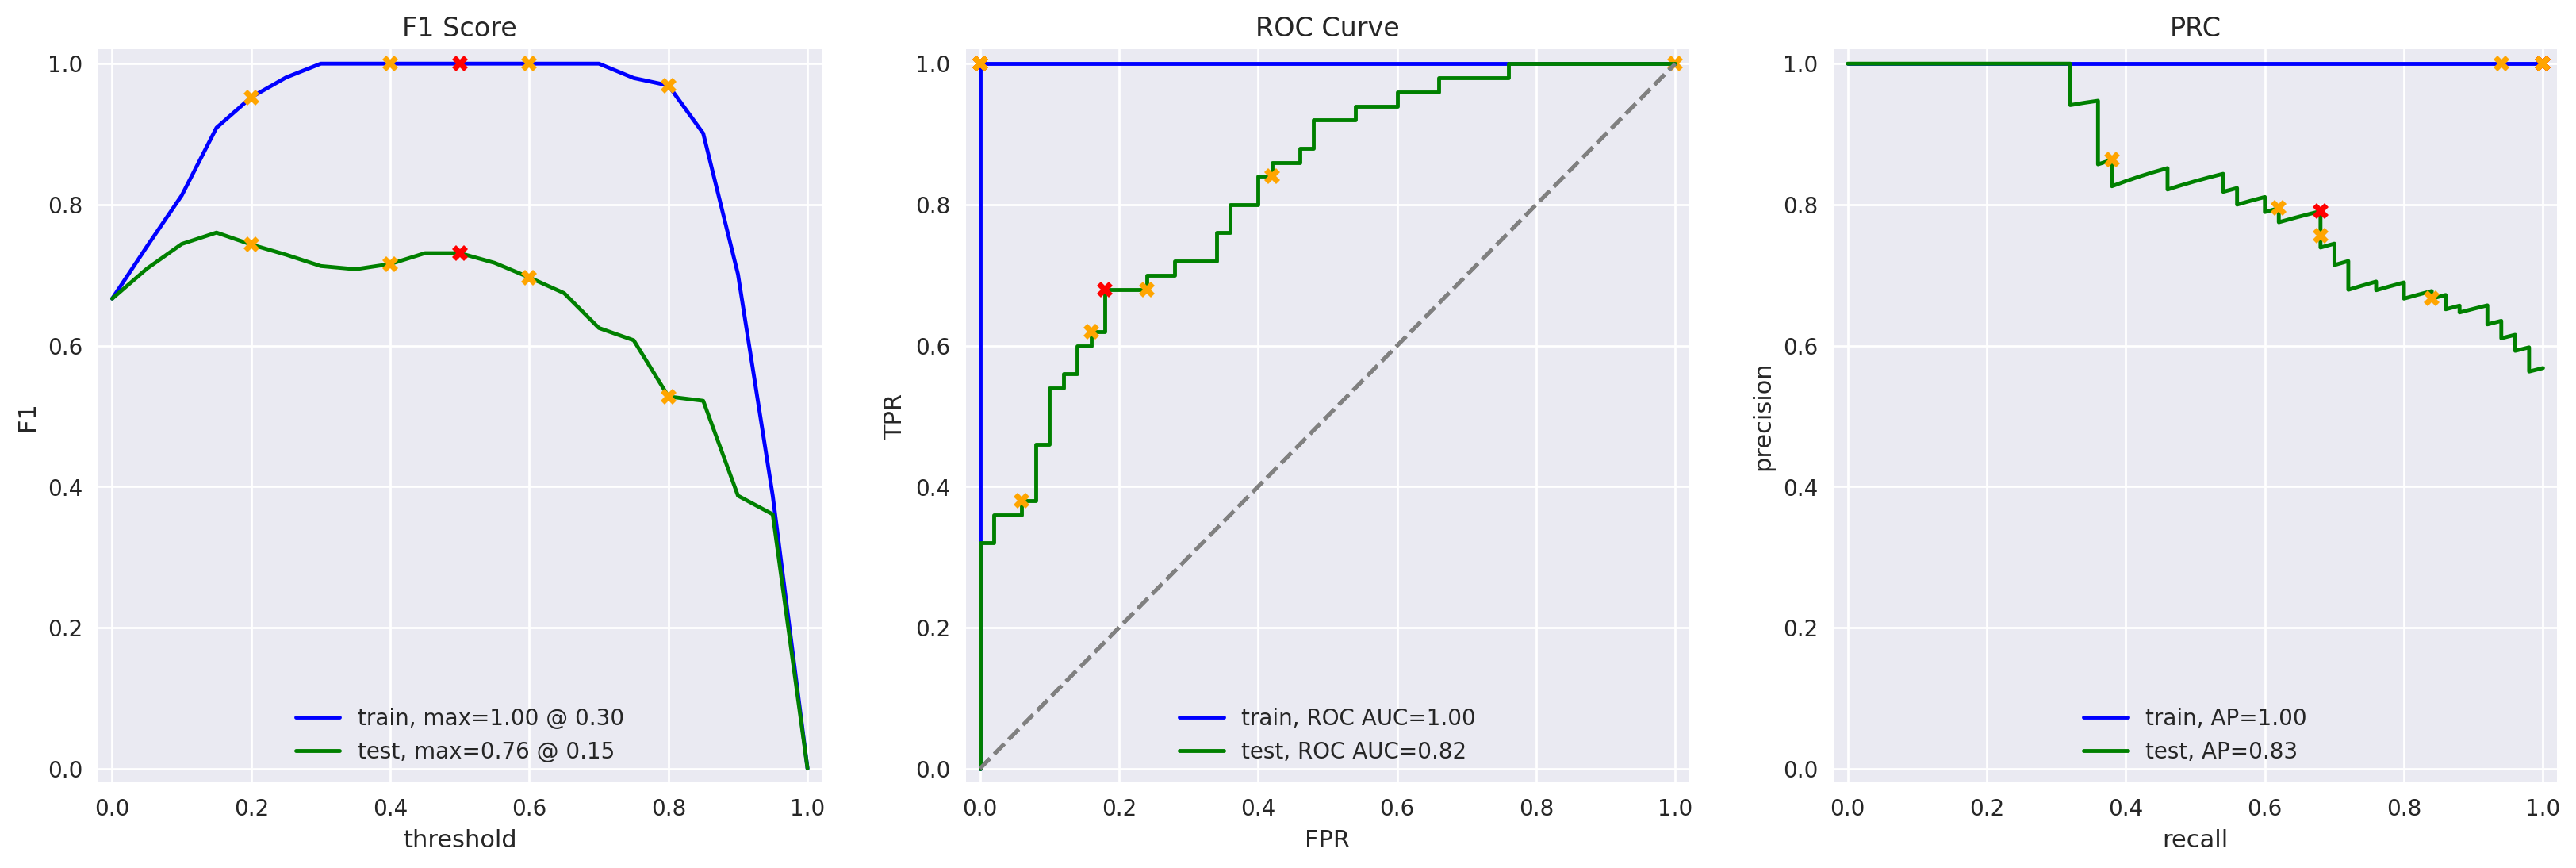

In [42]:
model_9 = LogisticRegression(max_iter=1000, random_state=12345)
model_9.fit(train_features_9, train_target_9)

evaluate_model(model_9, train_features_9, train_target_9, test_features_9, test_target_9)

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 9 Results: BERT Embeddings + Logistic Regression

The BERT-based experiment achieved perfect performance on the reduced training sample, with training scores of 1.00 across all reported metrics. However, the test results dropped noticeably, with an accuracy of 0.75, an F1 score of 0.73, an average precision score of 0.83, and a ROC AUC of 0.82. This large gap between training and testing performance indicates clear overfitting on the small sampled dataset.

Compared with the TF-IDF-based models, the BERT experiment performs substantially worse on the test set. However, this result should be interpreted with caution. Unlike the earlier models, which were trained on the full dataset, the BERT classifier was trained and evaluated on a very small subset due to CPU and memory limitations in the notebook environment. As a result, this experiment serves as a proof-of-concept rather than a fair full-scale comparison.

Overall, the BERT pipeline demonstrates that contextual embeddings can be generated successfully in the notebook, but under the current resource constraints they do not provide a performance advantage over the simpler TF-IDF approaches. In this project, the classical text models remain more practical and more effective.

</div>

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Saving Sampled BERT Embeddings (Provided Below)

Since BERT embedding extraction is the most computationally expensive step in this experimental pipeline, the generated feature matrices are saved after creation. This makes the workflow more efficient by avoiding repeated embedding computation if the notebook session is interrupted or the kernel is restarted.

In this project, the saved arrays correspond to the reduced sampled BERT experiment rather than the full dataset. Preserving these features improves reproducibility and allows the downstream classifier to be retrained without rerunning the transformer model.

</div>

In [43]:
np.savez_compressed(
    'features_9_sample.npz',
    train_features_9=train_features_9,
    test_features_9=test_features_9
)

## My Reviews

In [45]:
my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = (
    my_reviews['review']
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn t expect the reboot to be so good write...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Custom Review Set

To test how the trained models behave on new unseen text, a small set of manually written reviews was created. These examples include clearly positive and clearly negative opinions, as well as a few more nuanced cases with mixed sentiment. This makes the section useful not only for checking prediction correctness, but also for observing how confidently each model responds to different tones and levels of polarity.

The same normalization logic used for the main dataset is applied here so that the custom reviews are transformed consistently before vectorization and prediction.

</div>

### Model 1

In [46]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tfidf_vectorizer_1.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.26:  i did not simply like it not my kind of movie
0.29:  well i was bored and felt asleep in the middle of the movie
0.51:  i was really fascinated with the movie
0.18:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.37:  i didn t expect the reboot to be so good writers really cared about the source material
0.42:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.13:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.80:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 1 Predictions on Custom Reviews

Model 1 produces probabilities that are broadly consistent with the sentiment expressed in the custom review set. Strongly negative reviews receive low positive-class probabilities, while the clearly favorable streaming-drama review receives the highest score. More nuanced cases fall closer to the decision boundary, which is expected because they contain less explicit sentiment language or a mixture of positive and negative cues.

A few shorter positive reviews receive only moderate confidence, indicating that the model relies heavily on the presence of strong sentiment-bearing vocabulary. This is consistent with a TF-IDF and logistic regression pipeline, which performs best when clear lexical indicators of polarity are present.

</div>

### Model 3

In [48]:
my_reviews['review_norm_3'] = preprocess_texts_spacy_light(my_reviews['review'])

my_reviews[['review', 'review_norm', 'review_norm_3']]

,review,review_norm,review_norm_3
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie,simply like kind movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...,bored felt asleep middle movie
2,I was really fascinated with the movie,i was really fascinated with the movie,fascinated movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...,actors looked old disinterested got paid movie...
4,I didn't expect the reboot to be so good! Writ...,i didn t expect the reboot to be so good write...,expect reboot good writers cared source material
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...,movie upsides downsides feel like overall dece...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...,rotten attempt comedy single joke lands acts a...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...,launching netflix brave appreciate able binge ...


In [49]:
texts = my_reviews['review_norm_3']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.23:  simply like kind movie
0.18:  bored felt asleep middle movie
0.53:  fascinated movie
0.20:  actors looked old disinterested got paid movie soulless cash grab
0.32:  expect reboot good writers cared source material
0.37:  movie upsides downsides feel like overall decent flick going
0.14:  rotten attempt comedy single joke lands acts annoying loud kids wo like
0.84:  launching netflix brave appreciate able binge episode episode exciting intelligent new drama


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 3 Predictions on Custom Reviews

Model 3 shows a prediction pattern very similar to Model 1, which is consistent with the fact that both models rely on TF-IDF features and logistic regression. Strongly negative reviews receive low positive-class probabilities, while the clearly favorable streaming-related review receives the highest positive score. The model also remains cautious on shorter or more nuanced positive statements, assigning probabilities closer to the decision boundary in those cases.

This behavior suggests that the spaCy-light preprocessing pipeline preserves the overall sentiment structure of the custom review set, while producing only modest changes in confidence relative to the simpler normalization approach used in Model 1.

</div>

### Model 4

In [50]:
texts = my_reviews['review_norm_3']

my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_3.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.50:  simply like kind movie
0.24:  bored felt asleep middle movie
0.62:  fascinated movie
0.25:  actors looked old disinterested got paid movie soulless cash grab
0.41:  expect reboot good writers cared source material
0.57:  movie upsides downsides feel like overall decent flick going
0.11:  rotten attempt comedy single joke lands acts annoying loud kids wo like
0.76:  launching netflix brave appreciate able binge episode episode exciting intelligent new drama


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 4 Predictions on Custom Reviews

Model 4 produces sensible predictions overall, but it appears less decisive than the logistic regression models on several borderline reviews. Strongly negative examples still receive low positive-class probabilities, and the clearly favorable streaming-related review remains confidently positive. However, several mixed or mildly negative reviews are assigned probabilities closer to the decision boundary, indicating greater uncertainty in sentiment interpretation.

This behavior is consistent with the earlier evaluation results, where the LightGBM classifier performed slightly below the logistic regression alternatives. On this custom review set, the model seems more willing to assign moderate positive probability to nuanced reviews, which suggests a weaker separation between strongly polarized and mixed sentiment cases.

</div>

### Model 9

In [51]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(
    texts,
    max_length=128,
    batch_size=4,
    force_device='cpu',
    disable_progress_bar=True
)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.28:  i did not simply like it not my kind of movie
0.11:  well i was bored and felt asleep in the middle of the movie
0.25:  i was really fascinated with the movie
0.12:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.05:  i didn t expect the reboot to be so good writers really cared about the source material
0.34:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.04:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.69:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

### Model 9 Predictions on Custom Reviews

The BERT-based model identifies the most clearly negative custom reviews correctly and also assigns the highest positive probability to the strongly favorable streaming-related review. However, compared with the full-dataset TF-IDF models, it is noticeably less confident on several positive or nuanced examples. In particular, shorter positive reviews and the reboot-related review receive unexpectedly low positive-class probabilities.

This behavior is consistent with the earlier evaluation results, where the BERT pipeline showed clear overfitting and weaker test performance. Since the model was trained only on a very small sampled subset for computational reasons, its predictions should be interpreted as exploratory rather than directly comparable to the stronger full-dataset models.

</div>

## Conclusions

<div style="background-color:#edf6f9; border-left:6px solid #1d3557; padding:14px 16px; border-radius:8px; color:#183642;">

## Final Conclusions

This project developed and compared multiple approaches for classifying IMDB movie reviews by sentiment. The exploratory analysis showed that the dataset is structurally clean, sentiment-balanced, and well suited for supervised text classification. Although the corpus is uneven across years and the number of reviews per movie is highly skewed, these properties did not prevent effective modeling. The main challenge was therefore not class imbalance, but learning strong sentiment representations from variable-length natural language text.

Among all full-scale models, the strongest result was achieved by Model 1, which combined normalized text, TF-IDF vectorization, and logistic regression. This model reached a test F1 score of 0.89, exceeding the project requirement of 0.85 and outperforming the other main approaches. Model 3, which used lightweight spaCy tokenization before TF-IDF and logistic regression, also performed strongly with a test F1 score of 0.88. Model 4, based on the same spaCy-light TF-IDF features but using LightGBM, achieved a slightly lower test F1 score of 0.87. These results show that classical linear models remain highly effective for sparse text representations and that more complex classifiers do not necessarily improve performance in this setting.

Several practical changes were made to keep the project computationally manageable while preserving technical validity. The original heavy spaCy preprocessing was replaced with a lighter tokenization and stopword-filtering approach, which reduced runtime while still producing a clean alternative text representation for Models 3 and 4. The same TF-IDF features prepared for Model 3 were reused for Model 4 so that only the classifier changed, making the comparison more controlled and efficient. The BERT experiment was also scaled down substantially: instead of running on the full dataset, it was tested on a small balanced sample, with reduced sequence length, reduced batch size, CPU-safe execution, and optional embedding saving for reuse. These adjustments allowed the notebook to remain executable in a limited environment while still including an exploratory transformer-based comparison.

The BERT experiment produced useful insight but not the strongest performance. Because it was trained on a very small sampled subset due CPU and memory constraints, it overfit the training data and achieved weaker test results than the full-dataset TF-IDF models. This does not imply that BERT is inherently inferior for sentiment analysis. Rather, it shows that under constrained notebook conditions, the simpler full-scale methods were more practical and more effective. A fairer transformer comparison would require GPU resources and training or embedding extraction over a much larger portion of the dataset.

From a workflow perspective, an additional improvement for future drafts would be to wrap preprocessing, vectorization, and modeling into formal machine learning pipelines. Using pipelines would make the project more reproducible, reduce code duplication, simplify hyperparameter tuning, and further protect against train-test leakage by ensuring that every transformation is fit only on the training data and then applied consistently to the test data and custom reviews. Similarly, using the full dataset for every model—especially contextual embedding models—would improve the fairness of comparison and likely strengthen generalization, provided sufficient computational resources are available.

Overall, the project demonstrates that a well-designed TF-IDF pipeline with logistic regression provides an efficient, interpretable, and high-performing solution for sentiment classification on this dataset. Based on both the formal evaluation metrics and the qualitative custom review predictions, Model 1 is the best final model.

</div>